# Lesson 127 · RelBench v1: run and audit the RDL baseline

Teacher reference · Three live functions own the experiment contract, checkpoint selection and seed aggregation. Default run replays complete fresh author artifacts and reconstructs a real input graph. PROVIDED = inspect; TODO = implement; CHECK = execute unchanged; EXIT = defend. Learner PENDING_WRITTEN_DEFENSE.

<!-- course-portable:start -->
### Follow the computation

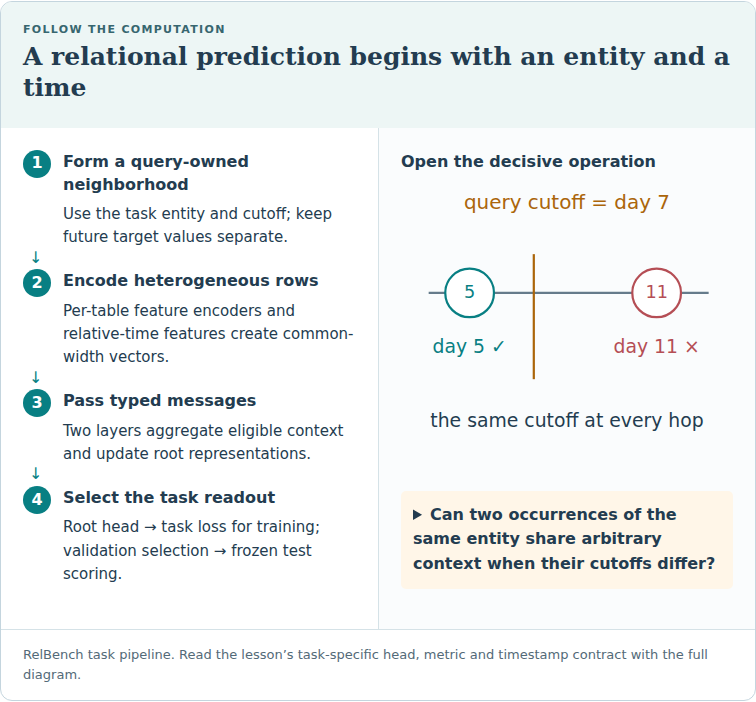

RelBench task pipeline. Read the lesson’s task-specific head, metric and timestamp contract with the full diagram.

**Trace question:** Can two occurrences of the same entity share arbitrary context when their cutoffs differ?

**Trace answer:** No. They ask different historical questions; context must remain attached to its query owner.
<!-- course-portable:end -->

In [1]:
# @colab-bootstrap: install missing dependencies; report actual versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


Actual notebook runtime: 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
{'numpy': '2.5.0', 'pandas': '3.0.3', 'torch': '2.13.0+cpu', 'pytorch-frame': '0.3.0', 'torch-geometric': '2.8.0.post1', 'relbench': '1.1.0'}


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 126 to this lesson</p>
<p>The API can score answers. A reproducible neural experiment also fixes architecture, fitting, checkpoint selection and aggregation across runs.</p>
<details><summary>Quick prerequisite reminder</summary><p>Validation chooses a checkpoint. Test evaluates that frozen choice. Seed standard deviation describes variation among fits on this fixed task; it is not variation across databases.</p></details>
</aside>
<!-- sequence-review:end -->

> **The win.** Run a complete RelBench baseline and explain exactly what its result establishes. You will freeze a configuration, trace a real prediction through the model, select a checkpoint using validation alone, and aggregate five independent runs without hiding missing evidence.

[Student lab](https://avistian.github.io/relational/labs/0127-relbench-v1.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0127-relbench-v1.html) · [Reference](https://avistian.github.io/relational/reference/relbench-v1.html) · [Reproduction contract and commands](https://avistian.github.io/relational/labs/l127-reproduction.md)



## 1 · From an API tour to a defensible experiment

In [Lesson 126](https://avistian.github.io/relational/lessons/0126-relbench-beta.html), a **Dataset** exposed tables and cutoffs, and a **Task** exposed questions and an evaluator. That is enough to score a constant predictor. It does not determine which neural model to train, how to select it, or whether a score can be compared with a paper. Lesson 127 connects these choices into one experiment.

Recall the pieces you can now assemble: [L122](https://avistian.github.io/relational/lessons/0122-reg-construction.html) maps rows and foreign keys to a graph; [L123](https://avistian.github.io/relational/lessons/0123-temporal-heterogeneous-graphs.html) attaches the query cutoff to every hop; [L124](https://avistian.github.io/relational/lessons/0124-entity-task-tables.html) separates entity rows from supervised questions; [L125](https://avistian.github.io/relational/lessons/0125-pytorch-frame-deep-dive.html) turns typed columns into vectors. Here the tangible skill is **keeping those contracts fixed while training and evaluating**.




## 2 · What the original benchmark standardizes

Read Robinson et al., [RelBench, arXiv:2407.20060v1](https://arxiv.org/html/2407.20060v1), §2–3, Table 1, Table 7 and Appendix B. This lesson pins the July 2024 paper version; “RelBench v1” here names the original benchmark, not whatever package is newest. The benchmark supplies databases, prediction tasks, temporal splits and evaluation rules. A model and its training choices remain part of the experiment.

| Original database | Domain | Tasks | Tables | Rows available by test cutoff |
|---|---|---:|---:|---:|
| rel-amazon | E-commerce | 7 | 3 | 15,000,713 |
| rel-avito | E-commerce | 4 | 8 | 20,679,117 |
| rel-event | Social | 3 | 5 | 41,328,337 |
| rel-f1 | Sports | 3 | 9 | 74,063 |
| rel-hm | E-commerce | 3 | 3 | 16,664,809 |
| rel-stack | Social | 5 | 7 | 4,247,264 |
| rel-trial | Medical | 5 | 15 | 5,434,924 |

These are **paper Table 1 counts**, after its test cutoff, not contemporary repository counts or counts of labeled examples. Thirty tasks share seven databases; a row can provide context without carrying a training label. Our executed experiment uses all nine F1 tables and its complete selected task. The other six databases are overview material and **NOT_RUN in this lesson**.

The three benchmark task families need different prediction objects: a scalar probability for entity classification, a real value for entity regression, or a ranked target list for recommendation. Their metrics cannot be averaged in raw units. [Lesson 128](https://avistian.github.io/relational/lessons/0128-task-taxonomy.html) develops the head/metric taxonomy; today use regression and MAE so the whole experiment stays inspectable.

**CHECK:** F1 has 74,063 graph rows but 7,453 training queries. Which number belongs in the loss denominator? Answer: the supervised seed queries in the current batch, not every context row in the database.



## 3 · Freeze the question before fitting

Our target is **Table 7, `rel-f1 / driver-position`, RDL**. At each task cutoff the model predicts a driver's mean finishing position over the next 60 days under the released task's eligibility rule. Lower MAE is better. Full task reconstruction and outcome-conditioned cohort caveats are explained in L124; we preserve that task definition rather than silently invent a new one.

| Component | Frozen released-protocol experiment |
|---|---|
| Database | All 74,063 exposed F1 rows, nine tables; test cap 2010-01-01 |
| Supervision | 7,453 train / 499 validation / 760 test queries |
| Initialization | Five fresh seeds 0–4; preprocessing seed 42 |
| Features | Released stype inference, pinned text encoder, per-table Frame ResNets |
| GNN | Two heterogeneous GraphSAGE layers; sum aggregation; width 128 |
| Sampling | Uniform temporal neighbors, fanouts [128, 64], root cutoff retained |
| Training | Adam, learning rate .005, batch 512, ten complete epochs, mean L1 loss |
| Selection | First epoch attaining the lowest validation MAE |
| Evaluation | Released output clipping at training-label percentiles 2 and 98; all final queries |

The data archives, source commit and environment have recorded checksums. The original paper's neighbor table says 128, while this released script uses [128,64]; released feature statistics use the database through its test cap. **Those are disclosed protocol boundaries**, not evidence of train-only preprocessing. Historical seeds, binary versions and exact training commit are unestablished. [Protocol ledger](https://avistian.github.io/relational/labs/l127-reproduction.md) · [Source pins](https://avistian.github.io/relational/labs/_sources_l127.json).

**TODO 1 — `experiment_contract`.** Return a fresh configuration on every call. Reject unknown keys and changes to the frozen values. A ten-epoch experiment changed to one epoch is a pilot and must receive a different label. **CHECK:** mutating one returned fanout list must not affect a later call; requesting test-based selection must fail. The notebook uses your returned epoch count and seed identities to check real run artifacts.



## 4 · Model architecture: follow one question through the computation

<figure class="stream-figure" tabindex="0">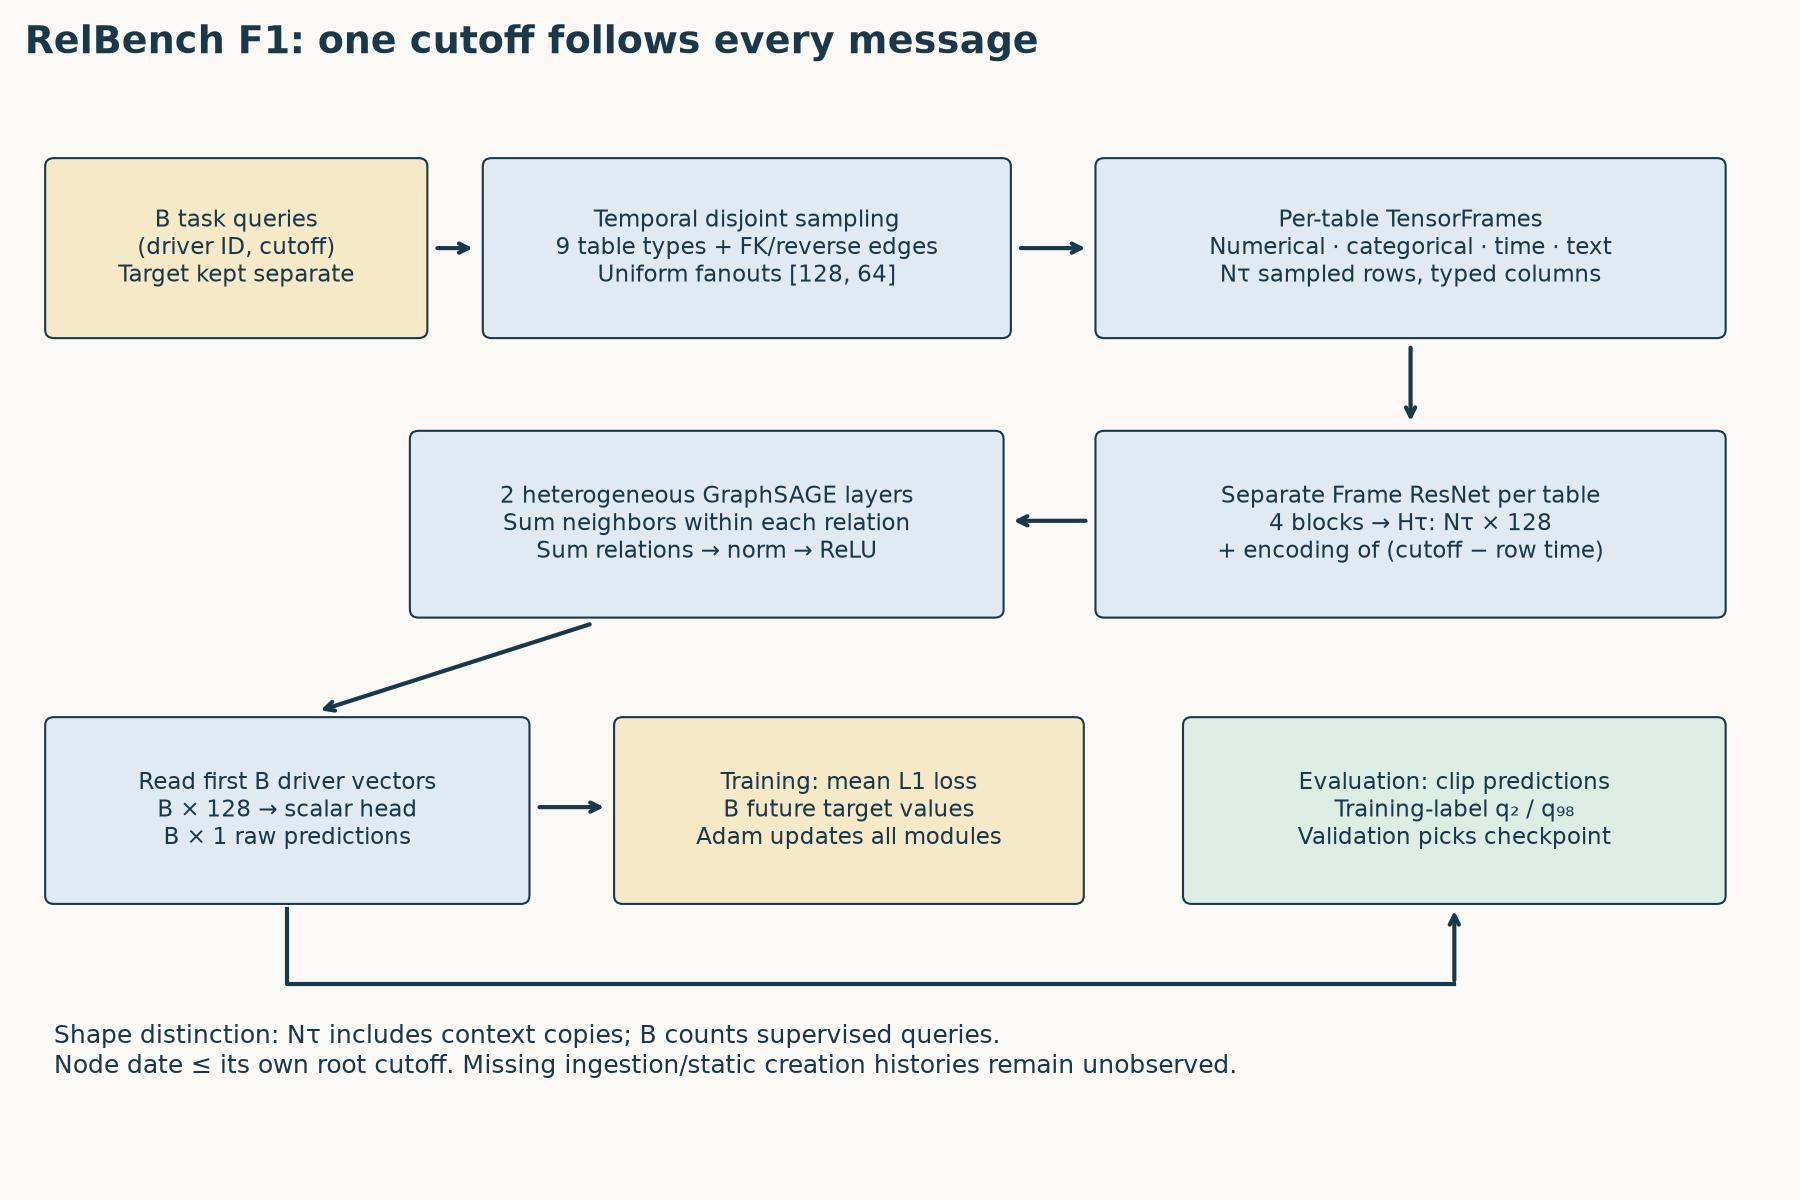<figcaption>Queries drive disjoint temporal sampling and table-specific Frame ResNets. Relative-time vectors, two sum-GraphSAGE layers and a scalar seed head connect to separate training and evaluation branches.</figcaption></figure>

**Diagram trace.** Trace one driver-time query through sampling and the two graph layers. Which rows contribute labels and which only contribute messages? On a narrow screen, scroll the figure sideways.

Start with a task row `(driver_id, cutoff, target)`. Only identity and cutoff enter the input path. The future target takes a separate path to the loss. Temporal sampling builds a **disjoint neighborhood per query**: the same database row may occur twice when two queries have different cutoffs, but messages must not cross between their copies.

For each table type τ, its TensorFrame contains typed column tensors for the sampled rows. Numerical and categorical encoders, timestamp features and the pinned text representation feed a table-specific ResNet. Its four blocks produce `Hτ ∈ R^(Nτ × 128)`. These encoders learn separately for each table because a driver and a result row have different feature schemas. For dated tables, the model adds an encoding of the difference between seed time and row time. Undated tables have no equivalent timestamp check; their missing creation histories remain an assumption.

For a relation `r: source → destination`, sum-GraphSAGE forms a transformed neighbor sum plus a transformed destination vector. The relation outputs are summed at each destination type, then normalized and rectified. Repeat for two layers. A two-hop result can therefore convey information through an intermediate entity. It can also be excluded at either hop by the same root cutoff. The source includes reverse FK edges, so direction and relation type are part of this computation, not interchangeable decorations. [Pinned operators](https://avistian.github.io/relational/labs/sources/l117/nn.py) · [Visible model](https://avistian.github.io/relational/labs/relkit/rdl_l117.py).

The final readout keeps the first `B` **seed** vectors for the driver type. The scalar head returns `B × 1` outputs. `L1 = sum_i |prediction_i − target_i| / B` supplies gradients through the head, message-passing layers and row encoders. Context rows help construct those predictions but receive no separate task loss. At evaluation the released code clips predictions using training-label quantiles; validation then determines which checkpoint survives.

**Read the executed forward path.** The released model first encodes rows, adds relative time, applies the typed GNN, and slices the seed vectors for the head. Optional shallow/ID-aware branches in the source are inactive in this experiment.

```python
def forward(
    self,
    batch: HeteroData,
    entity_table: NodeType,
) -> Tensor:
    seed_time = batch[entity_table].seed_time
    x_dict = self.encoder(batch.tf_dict)

    rel_time_dict = self.temporal_encoder(
        seed_time, batch.time_dict, batch.batch_dict
    )

    for node_type, rel_time in rel_time_dict.items():
        x_dict[node_type] = x_dict[node_type] + rel_time

    for node_type, embedding in self.embedding_dict.items():
        x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

    x_dict = self.gnn(
        x_dict,
        batch.edge_index_dict,
        batch.num_sampled_nodes_dict,
        batch.num_sampled_edges_dict,
    )

    return self.head(x_dict[entity_table][: seed_time.size(0)])
```

<figure class="stream-figure" tabindex="0">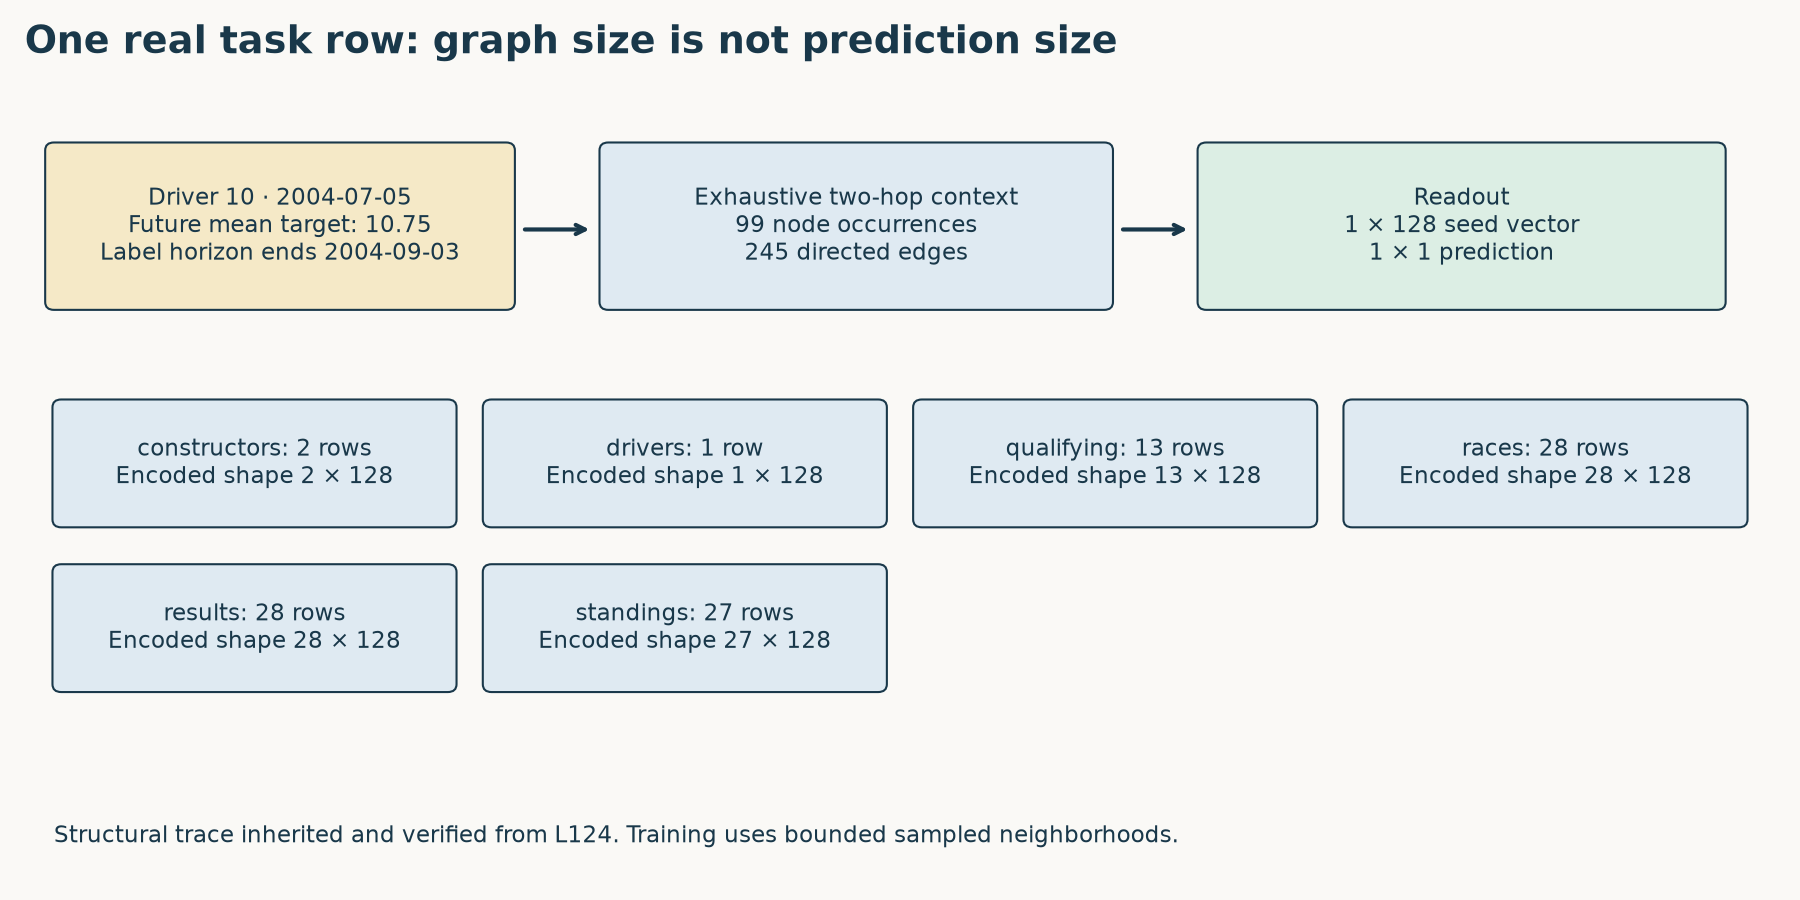<figcaption>Real driver10 query at 2004-07-05: 99 nodes and 245 edges in the exhaustive neighborhood, one supervised output. Typed row counts determine encoder shapes; bounded training samples can differ.</figcaption></figure>

**Trace task.** The notebook embeds a real L124 query and its independently reconstructed **99-node / 245-edge exhaustive two-hop neighborhood**. Identify the seed and explain why the output has one scalar, not 99. This is an input-structure trace; the training sampler uses bounded fanouts and stochastic selection, so this exhaustive graph is not advertised as the exact sampled training batch. Fresh training separately audits every actual batch.

**Predict:** if a result's event date changes from before the root cutoff to after it, where should it disappear? At sampling, before row encoding and message passing. Masking only its direct connection after two-hop aggregation is too late.



## 5 · Training is a sequence of decisions, not one score

Each epoch visits every training query once, computes losses on seed predictions and updates parameters. Validation visits its own queries without gradient updates. Store the first checkpoint that improves the validation MAE; a tie retains the earlier epoch. Repeat for all ten epochs even when the earliest checkpoint remains best. Only then evaluate the selected model on the test queries.

A sampled neighborhood adds randomness even in evaluation. Our ledger preserves both the epoch's selection MAE and the final validation replay MAE; they need not be bit-identical. The selected epoch is justified by the **epoch trace**, not retroactively by the later replay or the test result. Fresh final batches are also passed to the pinned original model with the same weights, separating model parity from sampling differences.

**Inspect the load-bearing training decision.** Notice where gradients stop for validation and where the strict comparison preserves the first tie. The loop records every epoch before the selected state is restored.

```python
for epoch in range(1,epochs+1):
    model.train();loss_sum=0.;count=0
    for batch in loaders['train']:
        batch=batch.to(device);optimizer.zero_grad()
        pred=model(batch,task.entity_table).view(-1)
        loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
        loss.backward();optimizer.step()
        count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
    assert count==7453
    val,_,_=predict(loaders['val'])
    score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
    trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
    if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
    print(json.dumps(trace[-1]),flush=True)
model.load_state_dict(state);model.eval()

```

Static trace: validation MAE [3,2,2] selects epoch2, the first minimum. Test MAE [5,4,1] would select epoch3 if misused. Changing test scores must not change the valid selection.

**TODO 2 — `select_checkpoint`.** Verify exactly the expected number of consecutive epochs, complete training-query coverage and finite validation errors. Return the first validation minimum. Do not read test values. **CHECK:** for validation errors `[3, 2, 2]`, choose epoch 2 even when epoch 3 has the lowest test error. Reverse the trace, omit an epoch or inject NaN: reject the record. In the notebook your function selects all five real author checkpoints.

This is the smallest local decision with a large experimental consequence. Looking at ten test values and choosing the best turns test into another validation set. The reported score then answers a different question from “how did a validation-selected model generalize?”



## 6 · Five runs: verify membership before taking a mean

Suppose seed 4 failed. Averaging seeds 0–3 and labeling the result “five seeds” is incorrect. So is copying seed 0's artifact into a seed-4 directory. Require the expected seed set, distinct run identities, completion markers, ten epochs and finite metrics before computing anything.

**TODO 3 — `summarize_seeds`.** Compute arithmetic means and **sample** standard deviations only after checking that contract. For values `[1,2,3,4,5]`, the mean is 3 and sample SD is `sqrt(10/4)`, about 1.5811. Population SD divides by five and answers a different descriptive question. **CHECK:** reject a missing seed, duplicate identity, unfinished status, partial epoch count or nonfinite result. The real-data harness independently rescores every prediction before calling your function.

<figure class="stream-figure" tabindex="0">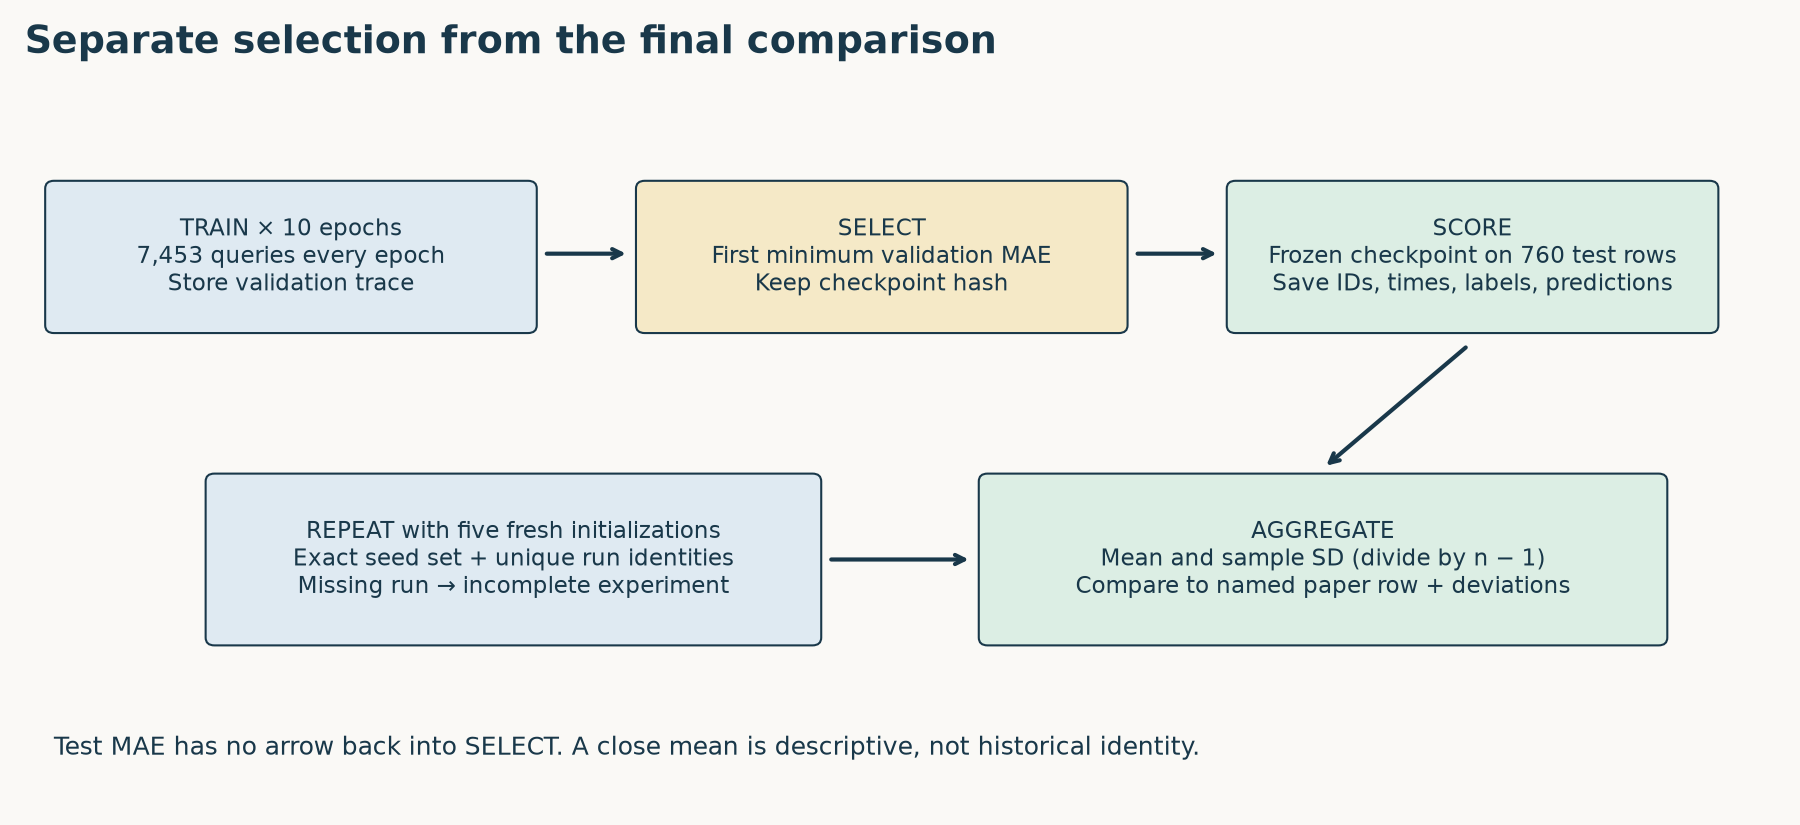<figcaption>Training, validation-only checkpoint selection, frozen test scoring and complete-seed aggregation are separate decisions.</figcaption></figure>

**Work a reporting decision with the saved runs.** The five test MAEs in this lesson average **3.967165**. The smallest is seed3's **3.824692**. Reporting only that minimum would improve the displayed number by about **0.142473 MAE** without changing a single prediction. It answers “which of these runs scored lowest on this test set?” The frozen five-run experiment asks for the aggregate instead. Both numbers can be calculated, but their meanings must stay explicit. [Saved five-run evidence](https://avistian.github.io/relational/labs/evidence/l127/summary.json).

**Try the omission.** Seed4 has test MAE 4.076791. Drop it and recompute the remaining mean. Can that result satisfy `summarize_seeds` under the original expected seed set?

<details><summary>Check the aggregation</summary><p>The four-run mean is about 3.939759. The original contract rejects it because seed4 is missing. Excluding a completed run because its test error is high adds a test-dependent selection step. Retain all five runs and report their mean and sample SD under the frozen contract.</p></details>

A seed SD describes variation among these fits. It is not a confidence interval, and overlap with a published SD does not establish equivalence. We predeclare **0.2 MAE** as a descriptive closeness tolerance for the mean; `CLOSE` means only that this threshold was met. A close score cannot repair a protocol mismatch.



## 7 · Fresh measured evidence

**Fresh author execution: COMPLETE selected released-protocol experiment.** Five new seeds, ten complete epochs each.

| Split | Mean MAE | Sample seed SD | Paper mean | Verdict |
|---|---:|---:|---:|---|
| val | 3.178174 | 0.022776 | 3.193 | CLOSE |
| test | 3.967165 | 0.093906 | 4.022 | CLOSE |

| Seed | Selected epoch | Selection MAE | Final validation MAE | Test MAE |
|---|---:|---:|---:|---:|
| 0 | 10 | 3.162397 | 3.158234 | 4.019688 |
| 1 | 9 | 3.149294 | 3.152550 | 3.955867 |
| 2 | 9 | 3.190597 | 3.189320 | 3.958788 |
| 3 | 10 | 3.186572 | 3.183047 | 3.824692 |
| 4 | 7 | 3.208308 | 3.207717 | 4.076791 |

All **6,295** final predictions independently rescored; **403,895** training/evaluation query occurrences audited. Maximum original-model output discrepancy **2.86e-06**. Pilot plus five-fit worker resource estimate **USD 0.063399**, excluding unitemized overhead; six bounded worker reservations consumed within the USD10 plan, no retries. [Evidence](https://avistian.github.io/relational/labs/evidence/l127/summary.json) · [Independent archive/SQL audit](https://avistian.github.io/relational/labs/_audit_l127_results.json).


<figure class="stream-figure" tabindex="0">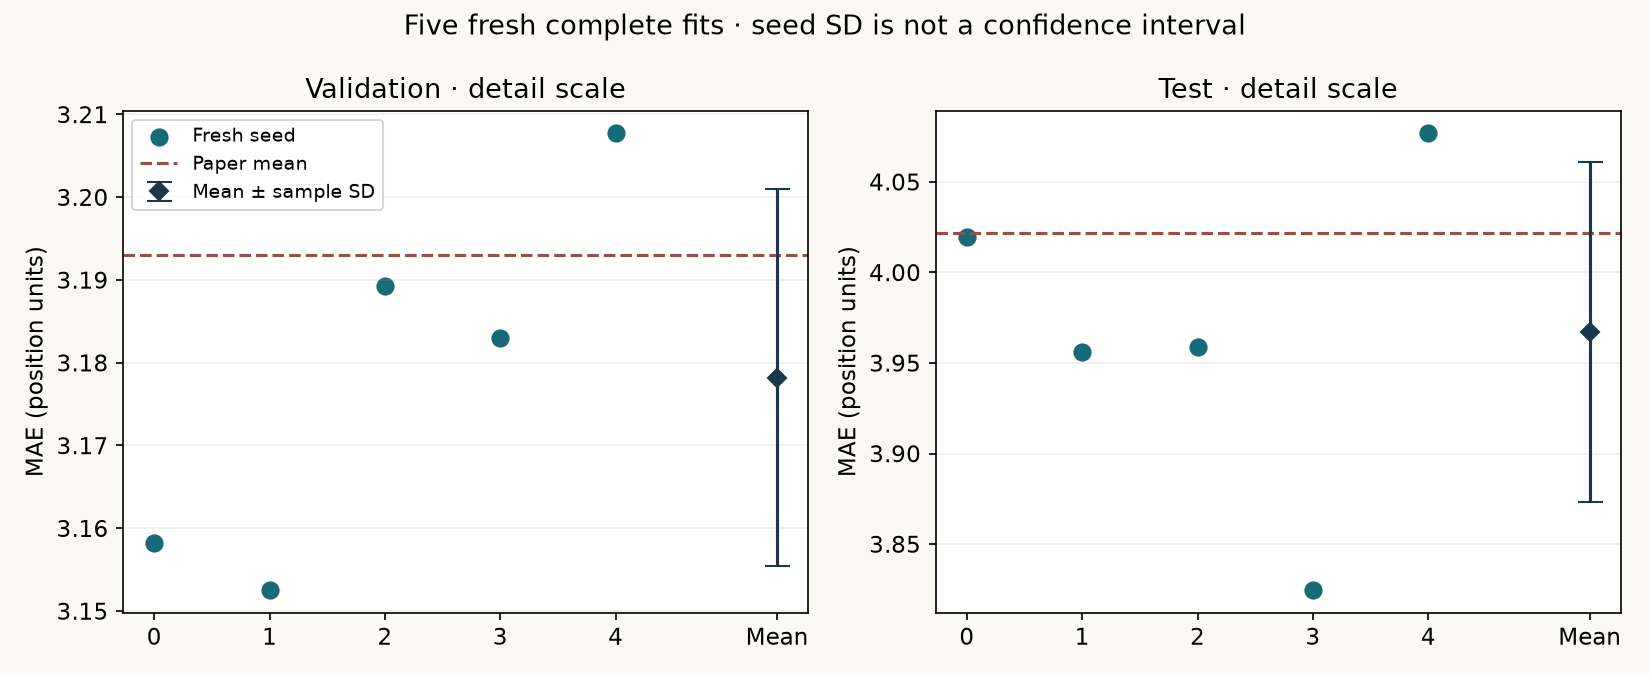<figcaption>Five fresh complete fits. Diamonds and error bars show mean and sample seed SD; dashed lines mark paper means. Each panel uses its own detail scale.</figcaption></figure>

The reproduction uses complete data and full epochs for **this selected experiment**. The artifacts contain epoch traces, selected checkpoint hashes, prediction identities, original-model replay discrepancies, fresh run UUIDs and per-batch temporal audit counts. The scalar scoring audit uses saved predictions, rather than trusting the trainer's printed metric.

Evidence answers separate questions:

| Evidence | What it establishes | What remains open |
|---|---|---|
| Source checks and fixture gradients | Included model equations agree with pinned implementation | Historical executable identity |
| Archive hashes and full query counts | Same pinned released data, complete selected split coverage | Historical paper archive identity |
| Batch audit | Node time ≤ own root cutoff; original edge identity; query isolation | Missing ingestion times and feature histories |
| Saved predictions and independent MAE | Complete final scoring and consistent query keys | Generalization beyond this task |
| Five fresh complete runs | Observed released-protocol seed variation | All 30 tasks or the user study |
| Notebook/browser checks | Tested local teaching package | Learner mastery, live Colab or deployment |

Author execution is **not learner completion**. Your status remains `PENDING_WRITTEN_DEFENSE`. Whole-paper and historical parity remain `NOT_ESTABLISHED`; the other benchmark tasks are `NOT_RUN` here.



## 8 · Run, inspect, then defend

The default standalone lab executes your three functions against synthetic counterexamples and the complete five-seed author evidence, independently scores **6,295 predictions**, and traces the real query. It includes the visible model, graph construction, feature encoders, loss, training loop and important library primitives. An explicitly gated full-training cell and the checkout commands allow new fits. Rescoring embedded artifacts is labeled **replay**, not fresh training.

The author GPU lane uses a separate one-epoch pilot, then five ten-epoch fits. At most eight one-hour worker reservations plus overhead fit the **US$10 aggregate plan**; no automatic retry is enabled. Exact commands and resource accounting are in the [reproduction contract](https://avistian.github.io/relational/labs/l127-reproduction.md). The notebook's optional local/Colab training gate does not itself enforce a dollar budget.

**EXIT — submit evidence and a short written defense:**

1. Your three implemented functions and passing unchanged checks.
2. For one real seed, identify its lowest epoch-validation MAE, selected epoch and final test MAE; explain why final validation replay can differ.
3. Trace the example query through the input graph, row vectors, two message-passing layers and scalar head, with shapes and cutoff checks.
4. Name two source/paper differences and one unobservable temporal assumption. Explain why `CLOSE` does not remove them.
5. State the strongest claim the five fresh runs justify, and one claim they do not justify.

For spaced retrieval tomorrow, reconstruct the sequence “pin → train → select → score → aggregate” without notes. After Lesson 128, interleave this regression example with a classification and a recommendation task, changing the head/loss/metric while preserving the experimental discipline. Lesson 129 will examine the manual-feature comparison; we have not rerun that user study here.

Explain the strongest claim justified by five complete released-protocol fits and the evidence that supports it.

Ask the agent follow-up questions about any unclear step, or bring your EXIT artifacts for a review. A successful run becomes understanding when you can explain both the computation and the limits of the comparison.

<!-- sequence-next:start -->
**Carry this forward.** Change head, loss and metric when the prediction request changes. [Continue to Lesson 128](https://avistian.github.io/relational/lessons/0128-task-taxonomy.html).
<!-- sequence-next:end -->


## Implement the experiment ledger

Each function is used below on real artifacts. Hints: return fresh lists; minimum selection is stable on ties; check identities before averaging.

In [2]:
import math,statistics,copy,json
def rejected(fn,*args,**kwargs):
    try:fn(*args,**kwargs)
    except ValueError:return
    raise AssertionError('Invalid experiment evidence accepted')

### TODO · experiment_contract

In [3]:
def experiment_contract(overrides=None):
    """Return a fresh exact release contract; changes require a separate experiment."""
    contract=dict(dataset='rel-f1',task='driver-position',epochs=10,seeds=[0,1,2,3,4],
        fanouts=[128,64],layers=2,channels=128,batch_size=512,learning_rate=.005,
        loss='L1',optimizer='Adam',selection='first_minimum_val_mae',
        preprocessing_seed=42,temporal_strategy='uniform',clamp_percentiles=[2,98])
    for key,value in (overrides or {}).items():
        if key not in contract or value!=contract[key]:
            raise ValueError(f'{key} changes the frozen release contract')
    return contract

In [4]:
def check_contract(fn):
    c=fn();assert c['dataset']=='rel-f1' and c['task']=='driver-position'
    assert c['epochs']==10 and c['seeds']==[0,1,2,3,4]
    assert c['fanouts']==[128,64] and c['loss']=='L1' and c['learning_rate']==.005
    c['fanouts'][0]=1;assert fn()['fanouts']==[128,64], 'Shared mutable configuration'
    rejected(fn,{'epochs':1});rejected(fn,{'selection':'test_mae'});rejected(fn,{'typo':1})
    assert fn({'epochs':10})==fn()
check_contract(experiment_contract)
print("PASS: experiment_contract")

PASS: experiment_contract


### TODO · select_checkpoint

In [5]:
def select_checkpoint(trace, expected_epochs=10, queries_per_epoch=7453):
    """Require full ordered epochs and select the first validation minimum."""
    if len(trace)!=expected_epochs or expected_epochs<1:
        raise ValueError('Incomplete epoch trace')
    for epoch,row in enumerate(trace,1):
        try:
            valid=(row['epoch']==epoch and row['train_queries']==queries_per_epoch
                and math.isfinite(row['val_mae']) and row['val_mae']>=0)
        except (KeyError,TypeError):valid=False
        if not valid:raise ValueError('Invalid epoch identity, coverage or validation MAE')
    return min(trace,key=lambda row:row['val_mae'])['epoch']

In [6]:
def check_selection(fn):
    trace=[dict(epoch=i+1,train_queries=4,val_mae=v,test_mae=t) for i,(v,t) in enumerate([(3,1),(2,9),(2,.1)])]
    assert fn(trace,3,4)==2, 'First validation tie wins, test must not select'
    changed=copy.deepcopy(trace)
    for x in changed:x['test_mae']=-999
    assert fn(changed,3,4)==2
    for bad in [trace[:-1],trace[::-1],[dict(x,val_mae=float('nan')) for x in trace], [dict(x,train_queries=3) for x in trace]]:rejected(fn,bad,3,4)
check_selection(select_checkpoint)
print("PASS: select_checkpoint")

PASS: select_checkpoint


### TODO · summarize_seeds

In [7]:
def summarize_seeds(records, expected_seeds=(0,1,2,3,4)):
    """Aggregate only complete unique runs; SD describes seed dispersion."""
    try:
        if len(expected_seeds)<2 or len(set(expected_seeds))!=len(expected_seeds):
            raise ValueError('Need at least two distinct expected seeds')
        if len(records)!=len(expected_seeds) or {r['seed'] for r in records}!=set(expected_seeds):
            raise ValueError('Missing, duplicate or unexpected seeds')
        if len({r['run_uuid'] for r in records})!=len(records):
            raise ValueError('Reused run identity')
        for r in records:
            if r['status']!='COMPLETE' or r['epochs']!=10 or not r['run_uuid']:
                raise ValueError('Incomplete run')
            if any(not math.isfinite(r[s]) or r[s]<0 for s in ['val','test']):
                raise ValueError('Invalid MAE')
        ordered=sorted(records,key=lambda r:r['seed'])
        return {s:dict(mean=statistics.mean(r[s] for r in ordered),
            sample_sd=statistics.stdev(r[s] for r in ordered),n=len(ordered)) for s in ['val','test']}
    except (KeyError,TypeError) as exc:
        raise ValueError('Malformed run evidence') from exc

In [8]:
def check_summary(fn):
    rows=[dict(seed=i,status='COMPLETE',run_uuid=f'run-{i}',epochs=10,val=float(i+1),test=float(2*i+1)) for i in range(5)]
    result=fn(rows);assert result['val']['mean']==3 and abs(result['val']['sample_sd']-math.sqrt(2.5))<1e-12
    assert result['test']['mean']==5 and abs(result['test']['sample_sd']-math.sqrt(10))<1e-12
    assert fn(rows[::-1])==result
    for field,value in [('seed',0),('run_uuid','run-0'),('status','RUNNING'),('epochs',1),('test',float('inf'))]:
        bad=copy.deepcopy(rows);bad[-1][field]=value;rejected(fn,bad)
    rejected(fn,rows[:-1]);rejected(fn,rows+rows[:1])
    for field in ['test','run_uuid']:
        bad=copy.deepcopy(rows);del bad[-1][field];rejected(fn,bad)
check_summary(summarize_seeds)
print("PASS: summarize_seeds")

PASS: summarize_seeds


## REPLAY · select checkpoints and rescore every prediction

These are author artifacts, not a new fit. Your functions determine membership, selection and aggregation.

In [9]:
# PROVIDED: real author evidence calls YOUR contract, selector and aggregator.
import io,base64,hashlib,json,math
from pathlib import Path
import numpy as np
payload = {'0': {'base64': 'UEsDBC0AAAAIAAAAIQAQgRsK//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAGwcAAAAAAACdlelX1IcVhsFGBBxsGJkBB2UTnO3HLDDsijwIgiAIzACKyFIZRAUZQVBRARWjiUpVLDFokJBo0sS4EqsEG7SGKlEajTHU4IYe92o0OVSJhE7+hd5v9557zv3wPvd9G5LTk1Lm2NpU2qySF5jL55fJw73kkwsNcsFLXlhatqwsf0luaVmB+ff59PzicrN1Xl6UbzFbe4UhLExQCl5rvP7vcjwT4oJNTzJ7hx0Y35/Ko31B9CYbGHnCn1zBmS1nI7h3MZjNj8pwHJpFzksLO36MJ9tGzMbuPLpqY7m9vYr0qRPZ6BBJfZI7V+ND6e5JRPHCSMzAPN62l5H1wJU3jujwdtBQaTKx7I6Ggbv5hO5SMN2sxOtOPo1RGdgtE3BMG0e2dW8gIZSrWnc6lwu0NaZT3RzOy1MGrl/wxfNDKaFLlByLTcDDtADRAyV1rgJNn/hT1iDlTJcRzz4fDiQtY6Z9MadXqfH+fjWXk9TE361l4liBRZO1TCoVUzJ3HL0TDBRXmvh2WEr0hqGopbIAPkwppDtPxq6rMt4dFUGjzBePRik3B+W0HxOI+j6fmG2RRO92Y5Qlggs+JnoaNWx/s4zieVpCbmkpXpKP6GcRe1aq2HFMz9GtWs75B5P2bRqbxQbrLRPXQkfSv8tIxmMnZs2dykCnFB/JPNqd1Hxq8WJwtTfFt5QcahhPsJ2ZPa4TeN0hY/IsgUNxanaeUKPZrCWxbSUixwVUHVnHFYmWHWPWUZqvpOrlLH77VUrdUDzVB/24/J4DdSILoc5aVnTl83HKWMyXwthfqiZh1lR6hnyp0kXzy0Ypvfkyem+Ppag/hO8mq7hhLGCxzomO4yosj6vxtgjEfSLQc9OJ6cZUrmS7MzsoGJXRQErbOO4/diZthp4T3ZloYuJpStAzKjrdylwKO3MmsnNCDjH+b/JUvJRSSyJ653Ca7mcie6rnqmscaz6uoX94GsJnSg5kCYQMSGgbcKNXIefzkgyaZUmUHZxChI8GS6wK1VElzdM3cD86ibbzWlb7V5B8Tcq6BAODToHMKEykde/rqOovLLQveB119JWG/d2eON6SIGtwp3FJBOZmHf+YpGTCeCnVGcVseO7BgT4XstUaNMMazh6pxOujFbQ0GOncJOJ2fTp7IpQcPmzkzy1hVHxZi6hiLCalgK/P66i2Vwup+qM/gS9sCY30Jv6OH+e+yiOmyETeL4E42qawVh7M5WkKOh1dmfK5nvezNKw94c4M22V0SCpIuKKloFRD33s6Glems36XC24ugUTtW4DXoIajcUE8IZ2C+nCKHsq4WB9A9MXxNF9X0x8jpcCuhvYWHV5VUsS13mw5LHDmmhu2mSGcSJVCig8P31fxwd8ErnaHUrBXwvBnGWwdUUqHUI2vqpDVz0fzQurIbKcKVhWpKaxRMT0rjbf9ZCi6RnNTJebGFi2dZ0ooeCLhHfc19Oe5cvaklj89m8AKK/v/lSjxnutJ09cj2bZ7ET139Mi+8KWoVU3cfiW3/m4ktGo8NeuXkhxQy2+X5Oia5NQlp1P/bw079vszOH8x7fUm6oMEgkrsOfmfWsTX3Xj+6wz+WablVake9aYA3GqdqfUKI3FAjMZBQqxHCfYxibR15dJl1SBmuROOXykY+KsvfRYjaZ4yPl0kRjgQTFluONW2MuLfMtK6TUWAWMfP8X4cWlXCkxgzZe2O7I4exctAJR33lMzcN4m9zcEsbBNQFc/H7kgko2tE+DycyR90I1h0142VOcEE33Bm8EoYqqpM0lw9Sb3ggvhFKg/GGKhsMlLd5oF7Sy6XFiroe7iQ1Rv0zLrsj3uHhmf7yzk+V8mWxyJU28fSL3UnQ5FEf6YrA8k2+Ihmc++DAKLuqbk1VctPA3I8kzw4KNXRuc2PDV5qFCcNtPpIWOwTwmsXLTFPzfwrK5I2D6s/j/Ej85SWssXlBK8dzZIVApE/mfE+b8/zR364npSjDVlL1VYZlYELaAk3oIqXMe5wKDFv+TNtjwa3j/w5uNJE9fPhqN3WX+1PU3FW5UZPq5LeURNxKVVQcHUuwg8ziJwSy94VQTza5oZ+eRG2Vp0fOFiwUWvpHrJmS18O8ZuUOP/FZOXbDtPOSZwfEhh5R4aHLohTjZn8oHdg0kw554bMmFrlpFn57IsXk3CuhJHPNJy+kc0bIRJmB2TQaBDz9buVfNkdx6J9JtaVh/JYGowhW8I0DynftPjRpZNyLSKcFouOlEgF4lfpvPOjPYFH57MpfzS+Fi0pPQK1Yj/qvhM4tl1PQpIrC8JMeHwzkxdZbrgcD0d0KoMrjoGEJ4xF1ynGTuKHpl1EYm4R0tMiJufMISbPF6d9k0lx96HE3ppldak09Vg9//kcUrsVDD+dSPWNAqY2rOVajoTy9VEUWJnduX0Nrf4Kjh8xseaWitgRNVRM8uN/UEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAGW2xUf//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAcwgAAAAAAACdVntck9cZRqROERBRkiBJCCGK0BBy+RJCQPQRxUsLigRB7oSrgmCBoaCmtdWtXmZbpZZaCjTSdavXKXbtBKt43QodWqW2VcusZUhRmfaneFndd940qf133+93fuf2nnOe53nf855ve0Jy/MIlI1yqXVYH5xdU5lUEm2TB0YVcsFIWXFheUVWRW5ZdXpFfwMbjcksrC/jxyuLcFQV8f2qEQa0MUcrWyv7vzz0zZgPcmySoU5qxZ38SopbV47zUjEnXOGy+thEnu4vQKUrGgzkKGK4kQTwtmcrzh5Nx9kMbzX/y91S4bfenPZjt03NWtQCrZumwb7UekytFGHswCadlKVCskGPXuYV0lveOQOybm4EKoQHLmszUnvm2F2Sv6WAq1UH5Xw2tG1wmQcKPWdSeH5+JfymlaG0ahykZuVhdG45RR4MRtysWya8mOnkwzOfHK8B4mn6MQYI1mvAzzAzvcK6YcLLCxhl+tqYsXkE2bMxnpACTNhvwSaUOl+fnYGeYBDHhJVj14hK4zOVguiXH8REJdJ7pmAHVuzn4zJ4Im0WJBuEKXEk101mhE+wasX65tRxz0v2IK+McMFaNnugc1M7WwLR3HvmC2ZrNAYSdYer3UBAeTXEkZNWZ1H54JhXbYv1gvWtFjyoKTSIRtWcb0wlPs8KEjpoIbHlkwfRAEd6Ij4B6igFF63S0vu7TRNzbJiNb5hfvEDnp6/DDzt9IMUOyFANPEqE9NBEXw/RIWcOhKX86pr4hhYsmEd9lBSDkzzy+ixonH9e+bLxjU0L4Qhw6vRKhaAgiDg6/1NVLnBxZnJ1Q2HGz9v7HAuSYbNi0Lw9tBRGY0ZGFliMmfLzciGsvGmFZJ6I9TskK0P0+hxo3I+70cNihFFDsWcakkz9t4RJ8/spyJ5eSlRxxDEgPxMMcb4zcm4iS3lCMLp2EWxs4JB0MQ6xbDla8pULvRSA/U4nivkSKiV0X7PiY3g4Od55JoT7p+FMxOh9FQJekx9VhPQSr3iUb28NJ1P7IzUB2H8xZQpy3Vktg1agxekUyrseGEz5Wuhs9cWkmRxzStovR6JmK9UYlsodCMeMP/vj4cBpapOE4dsADPTcXwfdJPFxT8rEoyEQ4mW5dYgEmXLNryPRkOB2Y41R6qveNFRIfho2VD114bc5l4UqHgea7v4wgDExPpuUP5zlc/cwXY07mUnzUlQRCEZHsxO3QmNXH/+OB6Pf0WCZQoSROQ/sExooRZVuElBueqK+PJy0S1i7Gzleasa7xl1hw5KHmMDFsEyIIiyWBw6wbkdSOVCsIb/8zHPXd+kvho+XzyyE/dG5JwYV2Me1xu9d+rgOfAxs7d8sZNTwvclis18BYpEdtlhbXq8JR/yAVtaViDIuU+PJ+KD56MwYXdlQhbTABoddNtPbScjnFcZq7Dgs97THt8DUrWUot2r+KoLGjh0Ro5vOFdLcO0ao80s2skKP+sC/t9bRuLiIOt7s8CfOxPD3O7FsA+Ug+Pr4Iw/fuyRhv9cT6YU+U8pqwmKuq9nPeF1Z7rRE68xqrme9tYQKsjH2N4oIVNsd8yXIz86vDflaP3ae9C4LwRy4D0vF2DeMuC9F2zweiWTbsHpEH19MeSHukxVQ+vwUMqdE5KMdkQTzx/ub3adjWZcbc2/6oLvVG9wNv2jOuLB2rayROrqYuNf7yrRo/3QzBhN758HhdSFgZzj4vPdxTjPjBr5SwCUbzmt8q+FX8Mr6Mi+PdYYX1mf2DE75Obo53y809Ha4H7O+bdVIQ7WGOz7bH8LtyDHtkwVbOoV9lwGCvAVHuWpy4XIQ9H3DwCM924mZ549sjMnzdkAjzFSn5yZHXy54tR+Nof2RfyUNSdB5G8nc1K3c++UW00o9wvBxUBvWGCNR06jHwb3sMdZzSo3DuL29vy6e+pAPT4/wXUhpn/K5qfNG30P7+sr3Y+JuPJeh53/dXd5RpcPGmAct9dNja9iwi49S4o0t1xn+dTyHWnilCjFmPjdkceq97OONvQK3DVZ7PerXd9x33lqMqIxRd2jDk8GdUj/NCHx+H7ZcX4JJ/EdzmGYlfaq6Q7Hfz+Iv3S3CwLAp+uQroeaysBJySO/PSXS3/L8Dzm8jjZn3WZmsDG/zxN54nsxevDyIeVg1HvE7xvNj52hq771qilqFiuAC9ayy4UMrH0vUUmr//uRYevE/v90iwaTgbHX5eeMRy83TOeVbtYiFUSVHYdEnsxHyv1YiT7Rnw5e8r+StMhD/J7blxjSUTtwqNMBwzYl6XHqnf6XCnZCnhmFzL35WxWbRP5HP+hHnwxET48XfFoam2U01xY+2XYeTjHNKX2a+6WYzBITG0mxfhJbMUQ//MQvtdTyfOGI2IsDM9mpt4/TZHEp7CYiGmHDahkn+rbu4oRNtdAzJS9XisyMXMeQLi0LLFAPlXQti2WUiPt/yDCMPGKrt+OT/HC9P1mt6AQv7dZJifzpE+U7JxLMMXquf5HDx5Ef5qzae1rbzvX3gSSPvatgegtUjD53kOS/6hwZ5V/H9QjQZlFv4/JqMS9aYQNG6NxfivVRhomwnz+EScSw7FlrefwwI+7zO9emOnEeeqPF/ixx0XOnkfPCsnjEyv396x34WkgxKae/iqHGtCBbQH67d0B+LSWSHOpujRulRPHF96R0vvk+uNYkR/o8PUORanX1QCDRp2m/G7Th2OjJpG9qwMVKuwo88LBybkUKyzUtbGv68vRxFmloOG+FzEtGA4WT30c276bMxSNGZGEp+6vQJnbA/ckjj9uuSqPe9nVtjvh8U1iGrpeXs8Ovxyms9h6daJODQqgMbTu7XoL8zF8DQFnUn/pEctaBXo0JnE423QwLsuBPG6eHSMDkN0uz++XzwOzVo1/gdQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhABCBGwobBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAVkHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAeMLAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAegOAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAZbbFR3MIAABgDAAADQAAAAAAAAAAAAAAgAHDEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAXUaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAHQIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIAB5iQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAuSgAAAAA', 'sha256': '8b622dc18fb280870ca6c4014c4958b1499e11bcbd323c6c71ea1564ec8c6428', 'result': {'seed': 0, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.1623967635129877, 'scores': {'val': 3.1582338413399063, 'test': 4.0196881390454475}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 142990}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139774}}, 'trace': [{'epoch': 1, 'train_mae': 8.994080174102026, 'val_mae': 4.293062329977134, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.835616201902098, 'val_mae': 4.345783574340658, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.523647970662538, 'val_mae': 3.7657268029813697, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.399595966119023, 'val_mae': 3.7221704816850094, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.247546414856813, 'val_mae': 3.2567821882371515, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 4.950388206150265, 'val_mae': 3.3067615702698525, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.879419336954923, 'val_mae': 3.542951047651435, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.832344298680709, 'val_mae': 3.2466294100703443, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.7399056373339254, 'val_mae': 3.1842641365392734, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.709685967718053, 'val_mae': 3.1623967635129877, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 31.778816772000003, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '808ee9975667c2866415699e259812c8aa184d31248f89c2d48f3dd8eb90c74b', 'total_seconds': 44.811184471}, 'completion': {'status': 'COMPLETE', 'seed': 0, 'epochs': 10, 'scores': {'val': 3.1582338413399063, 'test': 4.0196881390454475}, 'seconds': 45.307969033000006, 'resource_usd': 0.010226914770128761, 'started_utc': '2026-09-27T10:28:07.664246+00:00', 'finished_utc': '2026-09-27T10:28:52.972244+00:00', 'run_uuid': 'dacb6bef-9bb8-4344-8d75-5429ffd45d76', 'lesson': 127, 'runner_sha256': 'c9c50f85ae28c853d9a57abcf3b6cc5a7f302869f2669935014830797ad78ff1'}}, '1': {'base64': 'UEsDBC0AAAAIAAAAIQCQV5OM//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAASAcAAAAAAACdkvtfDQYfx0vKJZ3jFOW06KLT6W6kkku+b2tCThc9FRrRKSVWqEl5KHfGXOe2FrlVZmqGbS9JopAhjZo9udYOhjJ6PC6Rx/MvPJ/fPu/fPpctoVG68EnGRvONFmoTEtP187RDHbTDZwzWejpoZ6TNy5g3PTUubV5C4v/46Omz0xM/8PTk6XMSP3jXwQEBnm6eDosc/m91ry9plj0ygdd9ayXxbBgDXrmQ9sYb/5OOZJ1skm9yfThz42M++SGF1etDyFiUwk6/IE54PBVn9WbupI+gcPIKvL0VrJkYiKbilfyc70e0VQQHGvRov56K7coePCoxYelyDRtmePAsfiKlxv3J2xTL3vkW+JywJC02ifRUPbqubvzd0C5p1+ypER9OrzHHtsSGH0/pOXrVF/Or9mxLt2KuvykO21XsOBFM9uVE9pUrWLbbHX2clgHfGqS6XE+9yob2bfO5EJhG0E1XqnfFk9yooF2fi996FUUjHFlT0Syjd5mi3+vE0RN6xt5tEafX38vs1Z4cqktioeNj8cpvk8+6BbK+WoE26LXMPdOfp2P6UXtcj+b8KHTXu+C5cyhHDPF4ljpiZJZJlxFuGOd7ELslltBH1+Vyhoqaag2ZZnYsq3dliouOmffdqGqIoPGLMvH5kC9vUL1U/glDd7VK3OVJlKy2YfMNJQWDzQiItWRKgjHqhgQsdxkRcsCMd2ddOfSlE9okCxYGa8ivyiLi+WTWti8l7aw7QbdyiH2v5PcRobzc2iItkSFcW2nLLO8ronk/k7AN/YhoimFF1UM5vnsw2mRrls+B8oUWHHzvR6GuEzfXvZGZWS9l+V9DqIw3x7AulWK5KAcPWJF9aBEWyl4E2FpyL+SG/DA+iukGY6q/82ZOrhtjHnZm+4bbol3sxKfe0fzj4Sdou9jx6fFofJ4EM85Zif+HzX94dF8qvk0m6UEwUZ95UvYsknHj7Wg/GMjnntk09/iE5Wpn/lXrgC7yhay1eyHlY5Uon47F9nQ0K21Gkti7P7pfFahnW1LrtpzMjcEMGu5CleMygnUtsrvtwzdUDqg8JzC/sFgCr6bz5eWDMuu0houVnVjLC1lw6a34tA/A8MSBe8EKcs51SPb7OFLf9ELReFsarzlT3+HC5j5ZmLxcxD8r9KxYWyUtqgS62CswqdJz4MdB/Ds0B0XlHbH6xgF9wSHZoE5D4W1J1qqjsq3CGp2FmgOvEllySc9Xnb155TOe0HA/ooaYM+t4i9wKcaOxyI0/w7uwOWgBkSEL0Gxy41Yfd96f9yDp5wQKtrRKqvVA2JfCOk8nLl13x2R/BHvK/ag060qpix2amu4Y2ampndYqBQPm4N+3FyOLn0tNRSeODFPSY32H1Gt9GTj6hYRcUFDZ2odRJn1pbvOnI8ogV3I20rAuA6P9OVxWxrLsUZ2cCzovsUMSWZqnxDTFEo+3kZwyMqYm47o0NzTJ2Dn2TLRNofzhY5lx8gsMHU/kcwc7etRa4DJSw+ytNjittKI1plKGdSRzyutjgverMUmxImOjOQOr9RSZmLDFKxOTKzn4vrRg+W99KMvbwo5cJ/janb+eTmNRWiLnqgew4eQpmTdkMVX+rXLLPpg8D1eKXexp/o8luV4G+apwACqvx2J2+bV8fSiZ3wrHsMYwlbLGnuw1fyK/9LTixSsFYb/qsUm3JDrwbyld6kvSkmGMKHkhpef0bDlvzR971LSNsGFS2AKWdY3lSFaV5L07JwWWSo4WqRi5WEFZd3fyVjpxpy6FfUtGsrjn7xJt0BF147A0NXQmurMvO6c/kIQkb+p7TuTxRQUB2c+kKV/HEm8XYmr0RKwwg/WL0fn3oDw7iZmmHzEo0Yab4RpKJyTDTQ3RbZVSEdIkxQXGFP80FhPrv6X7hsMys0ckG937En9Mzfe3NWRlqvFco+RqLzeebe5D3Ak1P+0YiMeZd/JlrQZHXT+cHqQQYx1I8KKnsrXGmuQ4DRf6ZZEfWS1T7TyofhfHNK9a2ZWpIP+eA6VhqezYbkRO9QzqPL1RBXQmLGAg3V7bEzlJg7G/DQF1H7rs970M/6VVwob25pZru3QLVWDo8xHrbtux3jmG7wp1+Pwl6HKHcNjrueyaO5tbQbbkTcrEV+NG65gY1KqJFDS64vWLHssvKmTWICVFkf2J1JiifeLF3sxY3LvWiX+HiiOF8Rzu3BN/9xvSoXog5msz+PmYHV6vY7m9oBMFR6IYt/2RmJbNZPqokdRpItnf6s6eN4MoCm+Tp2ZGPLhqheObhyLZATSU2bP7bS9G75mLR/wVCXgQzebcs/LVwcGEfNSb0zO6s3VPb45GufI2vEVsjulxfBeCY1ub1N31ZcnuCDod70/pHwYxaTbIs7tKSmKbpNU4hffFT2TFxWhSj6uYkhfAwmxTus1zZ8j98QzbastOu8mklDoQeqknWZuSGF+0hPlhTRKjBOe512TMihzsz7miPqNn0yoVqxbkcjHBgv8CUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAJXp0pD//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAjwgAAAAAAACdVnlU1NcVHstiGCJoKGLUALP+Zhg9wWikKsj7ECPaIMoSWUQcBlBbGQJDJIajkVLLgUo1Ai5RiWIMVWxJgoRjrFK0EREQjRUVe2pGNtlcWQW1c99kpvbfzjn3/N5y33vf99377puC5RHBK6LGiTaJMoWERIMuTZjvKfgmzRFmeApJKWnpaVp9XEpaQiKNv6fdaEg0jRvWaz9MNPVVPnO9Z6hneG7x/L9/4t7SIkRsecESf61D+UUdpG/mIbdOB7dGCVzmp6NpXSEWOyWgu9YRHSM67Gg2W0XnNkjLivj89ic6RAQM8T3I99W5yg9a2U87PFEWr8ane7qY3z91sN28G58POSDztXB+1s11djg2LgHTfyNDTa2Ot1fPamRn3L3w1a9kQJcCtC6s2h4Tvw/l7YzVK/Dikj3mTW5hTi56NG2Q4ul+Z8zuWoCQF7DyIMwrvxeDePqfUUPn6sXxE2bC6+A9yggnGY0TflrTeNCR+9BYtls7S5YI2KeUQzkWB5cNwyxupwFhJ6Pxzmw5qkvs8Ox6KD9v6mENVj6RYGbWT2zVxam4cCoND86azzImPeEaUf9ocDra6ocYcSXOa1KkKNiVjKg9E1H3wo/HgnzPPhxlhJ0wdQeJOR7DkAqpdvG8HTJjPXK+7mInowsRvFOFDcu6eVucXMTxlGSosCtZgY5ALT7J72a1x5Q4FaxBaIKMr9+QEQ7NSjvuS3H523EHrq8lDhLdIPv0WwNEg5HYOc3Iyno0iPSWAK/74WWyDfqLw6HLsMVbS8NxaEQBC5/yW8nQz3kDt7/2hbI3AFlB5vyxxCU/aZhZOFKeFVXd57ipHXOgk318YjuWJqxFsLuAm3ZapGlUOLJJhSqJCg4z2xntsf+kFs+PKYBmL0xaLkeEqo1R7rWe1/F4DtwYYGVr061cwh7JOcfFAWIsnNvCTg+vwlk7KVqmD7P1WjWcYiXo9dOjercclbt9UZM3CQGnA3lOeLxn1pj0tnAYVH/E+6TjzbNalGcp4V/viXXn3OF5oYD7LNp0n1H7mqvA/XIaYjjnnOWj7OAJKfZXR0GyeBrHR6bNrGcxzgLnIPtxlBl10fjBTYbTP0qwoHGMuRtjMO6WHHFrapmoMACv3/FDuz4eh4rVHCfpdmpfB2tyNmtIehJOC+aBXCn/Oh0x8yFsZDZecsws0uJNRwWfLxW9xTGQnqTlux8pMVTSxhbuNt+/cl8xhBqdFbdFY/oGL6tjPX0mjF/8En2+cr7P3QAb1B4ORX5JHcu85su1OOqcgOpHRehZMmLNBUsdKtgxyB4pzFjueghY5KDm7dqK8RzvhBAJ7x+NNeXBHhn6c3rY3spI/HXzGL9jqd+az7Xgs2Cjcz8Tu2GDnYDxWaacMunq3KiET6MMjXNWY8rBMRaglSBzwQR8+cf58JduxbrL/gj82Fw3glaZ87jJUY7TN81tS6zJDgV7oHqXwMf6bvewjCnxeDZThoIbZt1EF8XIHjYy2utV3cojpNDuqGeEOaRSwNHkSNh/J0XI1qn4Q5MOXXvq2XezrjAHU42knKtw7LLeF/o+bupilrpGX4p9XlI7uy4y8LwgozmKJdVmiqvFXzHDjK0mXwxRRxQ+e9nPNVy2pps5RxnZ5r50vKzVY7tdHfO4JcWsNC+cPCeBa58tvIvNdS+3U49HpZGovvmUzb9whz2p+Bev9S8rV+LpXHsr1+owGfILpUiumoggFUPfuA6ep4Sz4qoEq+4KKFcncGwPNWrUS3X/k7/El7hY3h0y6pP/jffvMQs3y7slrI5G1WMzn/OCPd+j79lKzrfhiRil/Vo8tpej7/dKBE3SoNNNiUlZKdi8UQ5tS7IVN9WNzOzXEOcRBlGJDc8tS11vfmjSp2SQxcbqkWyjR2/hBBzd6M/jsuhZDyMclbEJuO4koK5eipRQc95UKJVQhQ9b396Onns8XqRH35ZBPk78Jnu2MmcP8xrai8ZrvQeZTUwre/WOkgaCtxfKv5JAVzIVrttkSDPEWPM/oyYF+UY9uprlaC9V4uSNy8ySfwcWK9Fn4nP88DBbZ9pfsz0N0xpc4KqZzLlWuf/AKA8fRAHuBh2KB5ScX/myHu5P+CWHRpihQI2RITE6TVjJ/rJCbK1LWf2t7JqJ36I793jMqU1rd+59xogn+TcWi/EnE48tx5VWXnS+S78d8kyxa/7Fh+ht1CO7WI/bp2W4MBrN5w0683+E1GJ7aL1D8WBeA6N78k2lEpaz9tp2sCVr1Qh9e9iKuTRQwOASLb+vxKdS3M2OXTXfrWuOWgTfV2DuZQHFeZ749045gmJ0HEfvvvEonRPD8S++088Ic9lVI/uk77/vjc99KexMeeOQ74DnMaFcX/KfUJGKP8uGGLP9AEeqbNA4RQ+bsH9YNfl8QjfHTnrMuiZG4CUVxxbT2s0K16ggW276f5EejwOzBTyOUkKashYeiZ38nYkoFnAuvJcFVq/gethcceAY9j2357hfzZdJ2V64PuYOwvxqjZz9th6i50aWUzfEzk+NxsxzqXxtXmwoKg/Z8n1L68YjrEyOcjcNlBOl8DF64cQJBbSeCszK3ooe74l4mrMQtxuckbvNH4bfBeD4b53xdBHDl6a6T3oNGFU8Ng1h7Vzvlo1tVt7ZgQ4cI+n1TtoAj9fk6aOM5jqSxPBeauSaU/+MSozcoR5meN8LL85LOEe7RAV/n0aCU7DNU45t3+itcflUJUNscxRKTe+K/IYv9yeLuzAZPmO1bOvhZF5zyWpaF2JziBfHLDHVIKpFpAXhzPv5PwCNz0uIx3KjwPm4iNuYJbfXLx2xxnWHayvHHDvFkeO+4mS+J6l3hjg/S1yohn0xv415eA3y8bY35PAbjYfP38fzM2mP7hQ9LqXKoTE2MEWnHEea3BAsikTPWinuvjvEDihaWK5Iiv8AUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQCQV5OMSAcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAGGBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAEQDAAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAEVDwAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAJXp0pCPCAAAYAwAAA0AAAAAAAAAAAAAAIAB8BEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAG+GgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABGSEAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAS8lAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAAIpAAAAAA==', 'sha256': 'a9cc196bb06b30b23e79d6301804b044239255cf048ae44efefe72570ee8f46e', 'result': {'seed': 1, 'epochs': 10, 'selected_epoch': 9, 'selection_mae': 3.149294017391676, 'scores': {'val': 3.1525501919493486, 'test': 3.9558673433253637}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 142994}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139753}}, 'trace': [{'epoch': 1, 'train_mae': 9.060793263599022, 'val_mae': 4.321931486824154, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.880950144052857, 'val_mae': 4.390051794466212, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.5657438926051865, 'val_mae': 3.817586146311992, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.424993204203577, 'val_mae': 3.7392210047485515, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.3812141574566335, 'val_mae': 3.660524584630687, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.205624948327819, 'val_mae': 3.2559627104856688, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.964540519890938, 'val_mae': 3.362522713247744, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.889361316783787, 'val_mae': 3.1725329599781835, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.820966487248824, 'val_mae': 3.149294017391676, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.762441535964038, 'val_mae': 3.206674116742396, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 33.282460171000004, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'dae57ec89f426d6f87aff325af83d03cfcbcda20bb2f3d2ad80b8cbae9a2a2c2', 'total_seconds': 49.435627329}, 'completion': {'status': 'COMPLETE', 'seed': 1, 'epochs': 10, 'scores': {'val': 3.1525501919493486, 'test': 3.9558673433253637}, 'seconds': 50.442926553999996, 'resource_usd': 0.011385977381768879, 'started_utc': '2026-09-27T10:28:13.440463+00:00', 'finished_utc': '2026-09-27T10:29:03.883428+00:00', 'run_uuid': '35b77dfa-bc4b-4627-9797-951e0b24708b', 'lesson': 127, 'runner_sha256': 'c9c50f85ae28c853d9a57abcf3b6cc5a7f302869f2669935014830797ad78ff1'}}, '2': {'base64': 'UEsDBC0AAAAIAAAAIQC1RD/4//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAMAcAAAAAAACdlPtbDXgex0sJJZXSyaXToXOqQ6ecOpVTyfdVShfVSXek6KLcGp0TQsZgkDI92LZ2TVpMw7ASsS7DurNZl+TJpWaVlsHsYmZdU2rbf2E/v73fP7yf5/N83q/PjpjEaF2qsdEyo1WuWdn6zAJXf5lrYI7G1V3mmpNfYCiYuyQ9vyAr+39+2NxF+ux+X58794vsfu2m0Wrdle6yYtn/PeYxbUbED45G8/fHwtY6hpJCDxKcAhi/wxOLw13iw7/80dv6E7EjHd/ccBqr01l8Hqx/NWVj1DqMOwJ5WbyGqMLRbCcUr3/bs3RTCBKfWSTFL6PMZjYDK60oemXF4f8EMChgCg1VORyc6ontrDjoUXCs2ZWKvSlc6zNgIlfg+o0toSPd6PALpLTOichYOROuGFin9id1+TDKG+S8/Hoc8X1Sei5GsmR1Iss2SukOD+KkXEtWxlDq1AZynzkQ/DydxhmpSK57UTM2m30tSv6mzePEDTl1Kg0pB7uF4jsHStTe1IfrCbfuErsuXxHnEgLom5LKs62Pxedt9jh3htBU48ho1SCeFgWQXDWR/YZUfr8zmOOdQ7id0L97YyFxPwaRtyaD7htqfMf58EOTjo/KPrE4zYUunZr2Ic4EZLqTmhdNsrkvo5bGssjmjnD8Xs+hQlMCNmhpMu8RGkk8zbNVGOuceXhKiluiEx41Eq6tS8Bpjz28G8wDi8lYSDRcf+JIRLcnFRaZPLuSwJSdKzgwzZutbotY/Gc5I7ZE0xrXLVRpwZSnOjMxsle8ac3GaaEblM2kdrQxk+q1bHroTGHANEKbR7H0Wb9+YsZv+Tbk3huIdTts+uNowrYm06m9L7ySXflWnsU/qhVUNjrj+EunaCxKoPboUHpuaMnfoWHyZQkfn/QI7SYVr9/Gsds8ktoN43kfmsztAXHUNEqxyIyn6PthTG9KJ/hlCOuro3innsE+Ew0Tpwsq9+h595dwbOsD2VvpzUGfgbTn2JKkc8KubTZ+CUs4vDCM1CJ3jnwr55LWjePBazE/G4akyhW/06uw/sqI5Ed+2Iz3QO8dw6gnZ8Taiizi5p0XNWnetI13YlR9n7CLkRCl9aW1xIfjw6W0jDKnpSOHdlMJu09YUnnAk7UHvChXz8WkNIvKOj3BBa1CkbSc+cr+uxoVInULpLB3FUXPP4r1vmr2v7oonJWLOZ8i427HLaEPG4/TEXfOSJKwrDLQ+FGw3pDE/mpBo1rK7r8Oo/2MwHVqIH6RVtjcmsPtlgxCO7x4YenNrBkalmesRJFsTd/WCcSZp3H0rJpjQz14uCqatDeCH7PH4HdlIrobUpZUenHGv0/8pMinrUxKyi+9Iu/aGNqDHLlVMQDdc7jebMarXWO4+nYCpyQKrEvh/ENrNkmLsSpNo6Msl674RJqedYmfT7SICeXZXB/qzB2VkoEL4/nTSQsuGj8Rfp1GGCrcsNyQxv2kT+Lpi/n8IbBPtD3z6GdExopqDZZlHtx+4ELS1cui5J+pGI8OQvWFB0bNE7hQPJJQKz2ZK0axt2ceDY353MmRc2q+MxuUBcytUVEfqMHucxLdFDHvtC/by5rFoar5mHkb0bInnJKx3tyd6U62jZy3dka49E2iRmbKzWRLXsTOob15Kqu/TOSm31h2p9pxXDqWm84y0h8V0Bbrgs0dUw4fCibxdgj1byWU9Baw/IOcMIknEe4uOG5O46AsAcXLVnFY1iWSFHIcwtzIzFBSO8+XzsFefNO0iMvLJnEyw5RtOdORbb0gBins0Z4IwDzCiKLvIhlREcfIB1LiVWYcs9JRJw9mWmcB+Q0jOZG1grA9jny1PgVrfze+rHbnVb4n8eqZhB2ZyLao+yJ4Sq842GrJ6o3R+JkZUf/beXGkQYdmgIqfO134+ooX65rdOX56HMtq/egO9GS1swcGhaAqdgCNZWoSSifimZSMTxM8V9nhiAK9vScl5RkUxT0QFuvUlG9J5NHjT8JksIIDNxzZ55nDwyB7nvol42fUz/h7B0Ks/Wl47I0kwwdtPwcLKw3k2F0SWQu6RFCtFI3/ANrDR3LNvT/PXs2HLdmkv46l63U04ZuDKNDZ8bJ5JvpTzpx9PRuHp2pKls8gLDCOfZ88+cmnEIPpr+JcjpLqEDUNpx1Q3dOybpuOuBEm5JS78sYkGdUaBSGLTPEuNEbZsYA9NgpGlsym6e4Yaj/E8qRpAMMrs1AfgyXr4+l5F0Hp+wSKDWak/M6E3nsyrgwaju6mYEH0eBLTlDxvXEldZ7d47Z/EnBctYmp1INH9fbh4Rs7rzQqs+v+UY1KfiHhkYOqZ6Si2D+TcY8HjjTFEL1RRnNArzhcbc2SVKzvLzanJTeXSBSve/RDFiF1yVr2ZTHfnGDa/8KElXsdGiRfJ0bnsmDmJq3lSJPtnM+lofweHWGNcE87Hwm5hp1zCILUXn1cWYm+qIKItj90z5PwXUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAO+TahH//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAgQgAAAAAAACdVmlUk1cahsSAWi0CtR0Ek0CEhIRASNjCot/To4KySBIUQxIWAcGtYhAQMKUsgo6OrdXRGatDURnHcR/r0KlbnU6L1Qq16umkgJxWqVqMgCOiFevk3s+kzt/5zrnn7u99nvd97nu/rWnzU9P1ri7lLtXigsLSfLM4ViiOXxwhDhGKF680rzbnvZWz0lxQSMZn5y0vLbSPlxbnlRTa+5LoKEVIcIjQIvy/v/HZLb/FwCY3uI6W4ZmyFF81N+Bqaxmq1sog2taAoL56NAdXYnKOP/IFa3DwWDktjz1r0VTzHp0XnK7C0T08aoOsfXluV4iN6TsuxYULMZjzniuuua+GaX0DDGl8COp19KwPmrzwTUYldpSHw/dBGW1PyuhidNYIzNsqgUanovuSz/vCJ7KYtpt6F6Ml1xfq+XeYPqkePetDMOdJANYJk2HZnObkQTCLO4QgPFc9ikf6uASKn2AmeI/ZuROcpJBxgp/s4T0T0jVkbHmsjVnSHomDkSLkvJYF/Xc8JFpzMWuNEZWj4Xg92Av527X0vKLVarTJZRhY9hNjeUeM+a9ko7q0jJ4V9AcurUm/4sNsyKu5lCvh/K1fGMblZELRL0LrX1NoLMjarXPdKHaC6VadgOKpcZeh6+cclkdjBerbuIiI3QTbIzVidWz7oqyR4nn7eDRWfDkN7aEmfPLEBfPnR+FmfQyGxDK6/0q3DrKznnQtiYsuhE/964jDZW8eJrrkQj3bgJTKewx/bDRO3ZLg0bi52Fk+CXEztMiVeIL7rhZvjVU4+awqyUSqKx+6vyfhB08t5AIh5eCIy4lVbk6ORGeJVWMobtJuMAwxn/6+Fqp1JriXieEXYcA/p4qxV6tGx3AMOjVcauNJixH+40XQ9cRge08wTo/cY4j2Ej4so/HMkPAw3Jrv5KK/oqQcPZsEOD+tj9kbOxfju4U4b/VG9I5IRIRJMeeIHmc+k2PCN8no7xAg1yuTamKojMVH/O3gEJtdT/vEjzt2mpAfJUa7SIZflstwraWJrplyl0vbXcej6DpxvJFyrrg4BveH/PF8iwbnIKH4SJHIrMzFQ5GUg/vYyaj4KRUjxQHQ7BIisdneH56HC0HhONBuZYQpGZjRl4JoXi6ub5ZSnMRv05c+ZPzUD6kPiT8JTgfm5uMyWvO7XCkfgo0Un4khqPU2QtkZQOeVj6UUA/En8SV/IBKdw/cYjqiI6mNKHh/4ssyJ2+FjUpdP72WeDClQ7yPC5b8pqR1r76uwfK1F1pYexro5mfriQN1a/Oz1LtrK3Z1acOShu7VukD4IpVj+UaCAx8w4tr3Gm+KV8+W0n7coB/7b/HHSzEV/nRH6LWwe6l6vouc68DmwkXNHRsQQBEVi2ekI7NwXDJVZBUuREg890tE6cTIawwTYbwlEB3cekFQI7gINDHHxdK9pA5sHk3NDkfKMbTtiTYr2Kxl8ZDF07OYJF4RzjMgf9EeFmfXbQYsA9+/cY4itl/3G6QyDVNHDEMyBbRHYJknD7H3+2DfTHwnZZaiptTIV+V1M3kk51dyonOu8L6Q+dZbrzGukJrG/eXiAaVxdTXVBCpkjsSS5mcTVsX7h62xOlX7Kx1aTCaYB1ocZMzhQn+pnZphr0bfUgAczuxnj+2GwDKnxwwq7xt/wwhyRhvJO9sxA/ud6rG/h4seWO8wRj7sMsXlloADaXVOcXAP9Q/HxrFDok4OAunm4msLqlOCs95Gj86wUmWML2DhJguG+Ifd/9Ev4Ei6Od4cU0ifrdy+0MQ5ujnfL0GWAyZ5bCJ+3vb2oDT2PjcVKVyHen27Aue0BuLwgEr80q/H5nWAMTczGOCYcWfZc78BN8sYj2VQs4Wlxy/Iq1ZYjr+ctMKJuhANmrR4nXtGjLDEIJWMW0rj0jXIoDpkmH9WLJdhWFwZfcwDVTc2/w3Bf8+vbO3h4kMaL+GNZCTtO+Pl52phlw2z+JLbIeOmNMVC632NevqPEB282xGBvpRRhfdMwpyoAEzbqnPrPGDSiNdqEjW+qEOenwIL7VmbqC/3t7lZRPnuqOdR+a4YRSxMDcfe7IMTbz+j9zQ0mzq7Djx9r4LspD7OuBENp51dc5OrE71PsjtuKOBRtYLHSt9fFH7tf5KWoKaweLYUDzpiTvSfOuFGeZP2RzQIcsPPwvRnp5EXOP17Mxs7WlI3uXgPi3snCZLMIlfoMOs9VKWlMXfqnoHNPMZ7u6mbIPbnmFgLHWdzrg8wVTQIGb4xxYv7skBj9h/X0vhI+fuM4kNVwaHtZoBHm1EBMyLb/u1hCkSQNwCJdNsWxosobZztM1M5QP49i/vNMG70rDp+OWhTItuumzZOP75OLnHpZ4LEQwn9xMDtai91lkzBvQI9jk3qcPvH44hHFTvzh7icEL0NN8Vg9uHh6LBZDwXLwmrNxpmMa9l0MRGaQESOb2HfmzGg0jApXTB/P3ukn9neXYNi3yJvijn9JLxuPxmDL+mAQzA6NEOxvKLOgDrcxoR9x0ZKUhd/NyqJ72z/RwGfnJGp3R4EvtEuUeL4oGrImGfoTo6C22W3ZwpEwXIjC7wOQUZOCwnoRZnyRBhxJQ3ibCB8odTTvE3+VqGJpbJjn/2EIv8clHDh4R/r6U4zEX9fvsHdhehWPzln/KMAl5X2G2CD9c7enovo1Lk7IY3ByfzDlqN0fQd+np6ftem9UITHR4IzLak0AKm3pqLXn/QOtiXQ9KVdPB2D87S6mUrgQROukXBpNx7lzCRTzxWb2LSW+IDgd/wBk/FteDhRJEsrn5Eb2HhPMX1t4Tv1ZMwco5swX/0KdcgGtY9vZfOuIS6M9h/3pvI2RHmX/F1NL7XeoxP6vk8beAWJjVbIBB9cp0XCol3FbosJHvnwEpiZh95AAkZe8kb7qR+YvnnL8F1BLAwQtAAAACAAAACEASMv/Xf//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEABAGAAAAAAAABoGAAAAAAAAnZi7blxVFIYHE5A1CpEdX4ONMz6ei8czY88tToSQfCo6EE0KqsgitigQQTaiQUjnHajgEeAl5gHgXSgAQUTB2Ov/1rBWlIbTLO199l736/7+46cfffLpG7Vvat92nl9cf3bVeb/R+eDySaff6Fy+uPr66vzLZy+unl/c7H94/sX1xXz/+vPzry7m68PHp8N+t9/4rvG/v3rt9huVP/908x2Wt8vZyGDVNlg7FjwSHJTcM8i9YTp3T/BtwX754w833yTBnv0vxzq3In6aWp9oDR/wC38d4WmVk9vvpHx6++07/7aeaN0sL2+/R4J9QfDDR1f7RdTDjP+PnF/D30n3d8Vnv/z1l5tvKjgSn/C3mu7vCE6jfucQPRhsOJ14byi+72tdF2wkPaM/nauwK3aEbvc1+2PxzT3svi64LYifLCe7sb8R5a2Qu53WddF7R/K14725Pez/gehs6txYeh9L7/iL6Jbio0S+FUHZo2K/4X5p8ED0DtN97LIuuoXW2KMlvPh3voe+13RO+x6Pp85fkKP225lB8G65/xl/+Ou7wie7zfVrcpy4fUxvE/G/q7XsW2Fn4Z1jjnSfCBbCi53RK3wQx0fCT3zgX3X9n6Z80HW8BqWvqqdzA0HFF3apWol+IUj8wGfSu9vnH9NvhX2AtXRuxc8bHy91r4h5turF+/jhPG+anwr/DP9W3M71b3q6K/sPEr4j3T/QmryHnyzrPuceao2fQW9VELyK6xL/E965XrEj+G1/P/EBnj3BE79va/IX9afQupHyOXTxh+Xo53O8phfi8zTVD/IT/kk+1P0KO8CH6LziR5wbCs+q6D6Q3FvRju4X2B//xW84Rx0gHo6F92/F952Ix/MO8qEn8DwQxL7p3jy/mX6GrjdbF6nOtDwOTS7qDPUMP8Qum4Knnpcjn8CB5KROcn8c48XzzZboHKd6kvsVwQo9THSeeof9mh5H5DmTJ+XpKscZ/oI9C+1vx3iiX6KvqhUpnyHXcoSvxGFLesSe2J04AiL/jugs+plIbyS58RfyPn0C/GLHXe/bTD898TNN/RX8rTjeaNfjdE716D99V+yHHkb/8f5F/QX29XxNfufcIk9Q1+z8IJ53u8J3oX3s23K+DP6heCTvTZ1P+kZbgxc9Nz3vmjzY8b1Ir5blUR9XouclnRdet/swygl+p0MdGXjc2xq94Cfke+hDT3pxvyA/whf+hf7lzz5XMC/o/Gzs/Qf50OBj7+PI/6GvdXzQob6dOB2795b0veP1wM4Rz+i5F/lzObZjX+L5v57kQY/kC/IdcTyI++XY/cPkOvRzJnc96qla1Cn0Zf/Bv6RzbZ+DQt/m/XXOa8h/75U6a3jeTHRXxd+e5wH6XNsnb9D/qx+sUp1wP8RviXf8atEX272R1wnbh85ewgNd8ilzBPVhK+FHr9gV+X8/i/rBv/ET2bEapjmR/roX67vnm/s+xwS+ybdVnqcW8Rr95c+zaOfFPGznF30M/Qh1nTnI/ue6vO/5g/kC/4z9eaH/eU6i7qb3Ae//6LeJw0VfaxB86EF9t/dt8I2ddyO9WZ4r2/FcbZT6EeVh7yO5T32HXsoLxONs4Ud2Hz+Br6HHie1zfkn/+4mfdZ2fxDrh9Rt5qJv4SdY3cwl1lrxIHgIfehmk/8Ai8df0fGpr5s4Nzx/k3dA/oq/qJM17TX+/sXu8uzAnjH0f+eizDR9yH/t/28/vJ/QB61E+v7eoy0aP+ZS5+GWar9FbIXgn4vP8Lz15HsFerAuXj342+uGG1wPeM3g3i+88wut1qOt4DP849VWnbidbL/Jb9ONmyi+ve09Cj/k9Zpj2u7J7O+l50/0+6veu5EEfY/cz+tFQF8qhy8tcGPocz//4LXKRL6gD9N3N9J88hB2JwzXR3XB5mN/iPEB9aye/XncIv+DBL4gTO0dfN3J8pqdmegeDT+oZ9wvBqdcFW1NfW742uvBJXsLuR7GeuT6JO+ojdbGI/z0OgdRf/Iy8+Zfshbzp3cD1kPsI5j3qyn6aG3nf2vS5L/RXntfxn23Pa+g3vMNV6I84bMd48jljLb0PqP+vpfrjfko8NP1d7l9QSwMELQAAAAgAAAAhAGXGe9T//////////w8AFAB0ZXN0X2VudGl0eS5ucHkBABAAQBgAAAAAAADVAwAAAAAAAJ2YTWtTQRSGb1uhKmItUtwoZiEmrWl706Tfif3UneLGhSspNkVBrKTiRvwVbtRfa5V5hDzwEnE2J2dm7pyZ9z3nzJl8e/7y2YtXU9Xn6kvzdHjxZtTcaTT777aa7Ubz7Hz0aXTy4fX56HT4u//pyfuL4WX/xduTj8NLvbW5UbcX242vjf9u149mqj+tiKpZfuwV+bjIlSLny7x+0TtF9oq8UcbXi15LrhW5oe+7YR+9Cd/R2Ne1ImeLXCrzVrW/O9X4ua4UvV30W0Vfnhnvvyc72J2SPew8UD8647S5atzuzSJ/SpqPddmDz+lqXNbCuSm8O8K1Fv6209U8GvZuF/mjGrfzvciHRXJe8Dcvxpm2oPUWw7nQGWc+4/C6LN7hwzzsBTtHASfwMR70D4rEX7fFn/t3xH/Cm+8YN47YB2/wZ13Hy5Jwauv85pVmu/dlz/bR4cH8JF6Qzj+OF/ZrHvuBB/ppu0UHZ+OO7vhj3ZXwffJz8l5L8WnczQv4mUfaoexfDftwXgJn498L+A0CD/sarwMu85KbWmdW/c53+KPjlfXBgXzSFo7ke/I7PICXcTSejLMv1rPf+tzguSv/o+3KP/cDzuBmvOBnU5L53o/XAwf8syP8ab7/8MMD4ew4tw5u+CF8YY/9OI8Yb/zisMgnE/KC6yHmGVf0afWzH+Ob8gD84Le+x3xe42fcOC944ceOc+cr/BY/Zn+O+7vSHX/Ox9hzv+M64co8cDJ+yd9odcDJeRO/AWdwc7yD6yP5KZL9p3ue+N3WuOs1dOeDraL3JPmOuKRuXtN6zEu4JT9kn7Rj3c+OV/tbqvdcR4T0F+vpVM+lupoGruDJPlPd5v6Uf/vixe+drsZdT5s3v7cSP67nEr+pbplUB6Ab7/TOYj/Ek+t11+VzkubN8QIeqX5Ieci47Ql//AH/8Pyu5ttOT+e0P6d7FD8wD+Qb1y/O/8bPcUB8Ov/B/2I4LzwtSHIO1iUfpvrG/KV7lv0YV7+zUr20Jd1xbl66Yf1a+Jgv1x8rgQek+Wtp/fQ/Avhyn+AXPheN9ZKfO49xv5of31spb6S86Xoo1eXOf9wr//q+AadJ+cV5yfdWwnMQ/IPzGzfjYtzSu93vGfpTHl8N/pfyi/PKsfBN724asMAj+GLX+Hq/6Z6xDs/Umb4H0v8A7qfedxw7X5i/xHdH/uX4Qvd3tDqsi13j4PxwIF58LztenG+oZ/k/piV/Ia8TD6xLXnd+//tuKP3UQdRF+MVAuusmx0fK58Y5xWt6h1g3f46XDa3r+Y5jx2Ed+AJf8AP39P8Mje9/AVBLAwQtAAAACAAAACEA7YtKSP//////////DQAUAHRlc3RfdGltZS5ucHkBABAAQBgAAAAAAACUAwAAAAAAALVYS0hUYRi9QmIWCWklPRaDi8Zk6G0PcREuFINKhYKikmmcqAiVmbGgaBMhopsoKHNh0Ko3IeGmwlUWQkK0S5RBIhcRFJkLF9VtcfByuIfvn7Fmc5i58z/uOd93vu//bx48fKDpaIF3wbscbUumE6loTSRae3ZPNBaJnu5IZVLx9taOVFvy7+/18fPppP97+ky8M+l/r9y9a2tsUyxyJZL3Z5nnPVzyLtuyyvM2zs137QvBezOVyzcHsORuyc/3ZZ53Nd3/fCCAv9pGG3t8vHRkdqorgHMNFZmEj6m9TcXNPp7b8HhHLAQ/r/j4dq2Pp34XnSwK4NS36h+zpZ53bDrRMx2CLa9Hhl75OD78teFRAOv6LhZlfKxp/7DtUAgOtxa8qQ1BvJ+ad/ROY6rbx4rymWfZlQs4uHR1/biP6+brJl6E4K0vnZ0PQrB0crDwto9VO/u6C0sXvvP8WB96Kd2g08DYtepiH288ybZ+WoROrrrsv79+sj/AD/i3dMC47c1bjleF4NO6E9/LAwieLL4t3oFqfujAz5l/1oHzBTqseTk0Nle2gNAF8dZ7vbZ3JICsFyN0Y52ASh/WKdf84Hks3cAnEPFs6WSN59+xH9f8yFcnpRfrw/nEeQR9gPAb9h3oxMi6qPGsC/sVI+Ke4x/j+DnWU3wrXhW/+fqSqgfsQ8qPwCOvx3EOPhbr87yO5ePs55Z/KB9x5dfye66LQKsOAPE+2B/3A6rOY17owb6g4hnrWHFq8Q20+FX9DfPIecv8MXK8sv+wr3DcKp44fjnPgWoc1rfil/MemKtvMl8Wb4g78IZ9cN1kf3CtZ/gf88jx5sqHa/66+qTVH3AcKn5V/4D3g06KR9XXKX6BrvHJ6/A4fm6de1z14v6AfZl1dK1rnM+uuilftvKF8wSIOMO+VJ+o8oN9R+kHZN14nX/Vf1t1U51zXftwpaNr3ln+D+R6peKL6zfPjzxU/aFVL7hPxLysF+uk+kPXfpt9kBE8MLrqxXml8on7HO5vwD/7kNXHAPkcap1rmEdGjm/FI/Nm3d+o/k35E/frnOfcj+K5qiPsO4yqboBndc7nezDl86puu/Kaa9+t4tL1/IP3wj7V+Sjf+u16X8bnJtbF+r/av8oX5TeWrv8rT9S5lXXAfhFf3NfxeNd7NPZzxT/+h/k5P9R5SvVPrvcsVp651gVLJ/Yb6z5a3RNz3WadOK9UvoTXhT9QSwECLQMtAAAACAAAACEAtUQ/+DAHAABMCAAADAAAAAAAAAAAAAAAgAEAAAAAdmFsX3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAAr5uJlKBAAAGBAAAA4AAAAAAAAAAAAAAIABbgcAAHZhbF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAM9HkMDFAgAAGBAAAA4AAAAAAAAAAAAAAIAB+AsAAHZhbF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhADq5G5mdAgAAGBAAAAwAAAAAAAAAAAAAAIAB/Q4AAHZhbF90aW1lLm5weVBLAQItAy0AAAAIAAAAIQDvk2oRgQgAAGAMAAANAAAAAAAAAAAAAACAAdgRAAB0ZXN0X3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAEjL/10aBgAAQBgAAA8AAAAAAAAAAAAAAIABmBoAAHRlc3RfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQBlxnvU1QMAAEAYAAAPAAAAAAAAAAAAAACAAfMgAAB0ZXN0X2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEA7YtKSJQDAABAGAAADQAAAAAAAAAAAAAAgAEJJQAAdGVzdF90aW1lLm5weVBLBQYAAAAACAAIANwBAADcKAAAAAA=', 'sha256': 'df277231a44309f78322050984a4f4676ea022dc0f84d856c302bd1c0d963f49', 'result': {'seed': 2, 'epochs': 10, 'selected_epoch': 9, 'selection_mae': 3.190596838640864, 'scores': {'val': 3.1893202414095363, 'test': 3.958787692136932}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 142994}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139827}}, 'trace': [{'epoch': 1, 'train_mae': 8.87621337705597, 'val_mae': 4.245928087279092, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.82601204728434, 'val_mae': 4.355371431135383, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.556435405624228, 'val_mae': 3.8217074569416747, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.414019346205193, 'val_mae': 3.7155164184774168, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.362188762967801, 'val_mae': 3.442653010157481, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.020570325064496, 'val_mae': 3.2274231135407208, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.881439608598609, 'val_mae': 3.2207812550709733, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.816141480681689, 'val_mae': 3.2041255422170427, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.7588578549452505, 'val_mae': 3.190596838640864, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.711355755221327, 'val_mae': 3.203124833218479, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 34.010314484999995, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '2d6e8b2e57b07c3d199e74647a3e3bc37b8f170c0963444ba7f764d4fdd2bd87', 'total_seconds': 46.974289111999994}, 'completion': {'status': 'COMPLETE', 'seed': 2, 'epochs': 10, 'scores': {'val': 3.1893202414095363, 'test': 3.958787692136932}, 'seconds': 47.644969695, 'resource_usd': 0.0107544225595554, 'started_utc': '2026-09-27T10:28:10.039491+00:00', 'finished_utc': '2026-09-27T10:28:57.684498+00:00', 'run_uuid': '54c98a33-b728-4915-9fef-fd650bbb3cab', 'lesson': 127, 'runner_sha256': 'c9c50f85ae28c853d9a57abcf3b6cc5a7f302869f2669935014830797ad78ff1'}}, '3': {'base64': 'UEsDBC0AAAAIAAAAIQBXOPVt//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAQgcAAAAAAACdlfdXFHYWxQEVZSiOwwAjDDA4MBRBSlBKVL4fIiBKC70XHRQJIsVgb7GhaJY1CerhBI2sZbEGjWtWREUTmquGYxRddI0IFhQsaCygy/4L+36794d77rnn3fe+iYgLj0rS1SnRWeaozS6eXeTor3KcPMfb0VXlOGdB0cKirPyMBUXa7P/xwVl5xdlDfHFOVkH2EHby9vNzdXZVrVD93yN5l9cltq6MoFrVLspjw7m5zJ51fr4EV6iRlw9Dv9UP2eRJtFtmYR4WRG9RFh93BxB8uVcsmpzP1t1+fBm0hvoyU9IjA0nS6mMQ6IdakYBzWxrqoGQ+XJWguaLPgNqT8Lmf0O6dRv4lR1YQS02gBYn3zNA2JuFukcmdn1yYIzFgW7UFVZn+lBvJ2Vmp5OI/UjDPn4IySUaghYwJBlaoC80Z3h3KrLMJtEXL2PLem5QfxlNQOCCMpqUQpm/GmRM5BKgzWTHgRF7GbMoCrFmyvoA9axTs/2DPB6NOcbTIkNHy8QTfTuCwe59YcfWc2GXkTtPoZH579UjohIygOh7+tl9OQPagOKPjhdVSDf98kMybCFiepk/GvqmMOZ/MQnNHKv+Tg+46Nwby3dg8L4alT7rFvR45kh53fKuUNL6z50JhOMeG/Ja/D2dvZ4u4eyAR6d1+oTUI4uucZ0IyM5qxDbbs2WDOngETymKk7J1iyIA0nsbhoygzG0HDtYl4BTsxWiFDFuKE7EouN/viaDZfwtNqF2r2FpC6TcG03jAuKfrERa9Qtn9niWRyn9idOwvTdhW1f8Zh0PxQSDd/ytXTlmRuCeJQpIx6r4nsO6iL5Iw+yT6DQqf8U9J3SyluTaemu0ko7o5lavN8UudaUnHKnBVNHaKjKoylh41oO++Nx1QnZjkYDmXTKYpeqnlWE039YCCnPOyY5xqL5pcZOP1ugc6NOAr89NnwOp17fXDA5xO2VUXy2siN5Y/9qT1dwCW3YD7s80KYOJG6852osxtO9EMpe7pisV+dhd78AOq8HbhUpuBgjyV6hquR+YWQaqTCo3UpKdUvRPT0Id1YG451heMlOSe+isum1qdBHH7myKk+IwZzXwnjy6PQw53FNzXkSGSUz9Sj8UQm0YEynKr+FHpGLjT6uRJckkvc9vlM9E1Evq9F3Eqfxfl6U2oupSAZ5squ08s43qjHjx8diDp1Rijr5rJxsSmh25pFbYYNSy7YMLsqgWjLFDzu+vJyTCTHtvmwdp8p52L1uK7yIbPKk7tNI1mxMYdTi+aRE+KGar4bB71c0RyahWzDMLLPeqGsS2PGgXHkfnCgQx1BwZkANGUmFHyuJvaJlLYPdmzofikST+Uxsd0Sb3m/eGxmgvaCnPsJA8K11JdXlW/EdK2Mk53WSDPUWN0O5PO3uoSKHKb8MIeA5gWUdMVR6dUpQsY2idVoOVJhRu9OOSVDu9VfKeGkokPstX4gnHebs+6zTKI8+8SO33IIGnwujp6158RpU/5d60RnqyXaUite/dwo4n1TuJ7nRahSzZO3NuhslfE4L54TGRLyH2Zzc1gRzkpL7DepmOm7hj+iHLid5kZpeRInozIoap3AuvsXRXV4Ib1h/aIjfzou0734PcaW12sVPErqFuUBPshXj2TRJCPcXqWzpAfsTieSn26G8qwhfzFW0L9zDPJV8czfZMvPei9Fm8YP768F1/aPZHVeAgcP2lBfYIfJ3625sXgu0W/i8K9oEbkxd4RFuwXZOgoMhm5Rb4gz6SMdibXWos0MxGXvC3E7PQwRc07EvjLhxRJ/duQ/FBfXTySkJYpd/abUjXwurviF89rYmeAhD7WDxtwIW859pCxfl0zLAVt0pGoC+h3pHkxlz3sNaqtmMWN9pzi+yZianpl83/dc3Nl8XjRURPLX8bZI7C04manhWp01xf4WjMtypSV/HHN1lMTXetMmHxQPjZ3o8hjS8kxGdeUzkmJGkPGNkm1SZ3rt5lFn0yzUd535tTuBx7r3RWC4Gcdu2fPsxzlUaIc6/iiJJ185of3WkEMRk3h81IGBPEd2eVvzRUoq5/bUi/4XfaKqZQydLm/F+ooxSAI06H9rx+2uZG7VzsTmGTR9MYU/xumjNE6j8IiS0gNz6KwZz9OYOGpiYzHzcSFyVRqHPl4XjS0KftluT4OzIWmZLqjvx3BB1S8Wv7fkekciLqcVPKh/LTpvPxTTqnP57qCS1EWx2BqMpu1ABLWNPaL7y9noPZnMxp5ITKLd6X0/ndAnL0TpjkExba+Cp63D6L8ciNVKDSt3KVHfnEVrYLcYNymBZfubxZa6SawttEJ5UkrwMQVGkz0Z3/RcxL9MoXh+GFGPRjFvVAAlP0WQlOtAVVKXqMh6IPQ6zbDV1WXNYDIKjYTEVWBfaEbl91O5tms0/3rrz6JfwylNcGC6Zwaqd2547jNj8clUNh9fSJValwbfIGoLu4XH+2I6FOMpGfo38qMWHJlQSHuDjP8CUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAH4WPa///////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAnAgAAAAAAACdVnlYk0ceRqyokAR1PTh2IQm5cDGEeLUe7bxWa8MlgoSAHMISROUSKLbWrdpFi25bq3hWi+IBikoViwdWK4ioCFStuuiiJZGjKOLJIaXufjOfyeP+u3meeb755vvNzPu+v3d+k9zA0ICg8H42WTafKuONGX9LV04SK6ckjFN6iZUJqemZ6bEpManp8UY6/kFsUoaRG89IjE0zcu+qiRM0Xp5e4r+L/++fffCFlVh66SW5OjMST/aH4a9JWcj7cySkEgXqryXDe98CzH8YB8k8R9xYHYmDp/k2Y0wywneuYt8nXYyF15NutgaNffNbU4WJKJrEeDfHGySiley1jUBF/0U4+4sIlyIC2V7/qheg8XQcss8pULQmkvVnCK6Q6itqaP7pgXwvOeg88QMBno4NY313UyjulQuQXdhI4pZGI5OLW6gdjnHmmRjp72vlQTGXPxGB8vx21jjkuI5l+ClmiverBb2E4qSNjlP8dE6M0JHF0LHmAjN5PsQbH+fIEdamx+Gql6Tm9nw0dc1B5hAlqncIYLfXj+334pwGK/KkuOphIg0iJ0Qumo/aHXPZXo7buphG9F2dnoBf87sJ5Uo5m9UyTGmIwqBaZ5Qc1rFc0Njra7oIxU4xbTwuYni+nOaJuB/DWN8udh6Sv2sm751aiYJQLfZWtLL+8rnpDE/SNh8EH1Mi4bEeD+42E+llDarSvVH1mYTNv74nAO7VAhZL8zK5SsT0teRhbetLkjEwAWvnhODrAWYS5qpB3RYxhvUniBUL4FToj+mFAiy84wfhDjksfN4aFIU7sSPRINHh5glfnL0oYhwseclx6yEWjtRnP8pbGG7aD+wzkc6QLHxx1ICK/ygxdqIBolwVjq/zwWe5GiwuaiJ0DadTYUjKV6K0SIPdN93R0mAm1Hu7YyJZPhOud5LpzxOtXAb+ScU4muWO2HLtLrmTMgu9s2W4/mgw9s/TQrTTHVunRGNqtQzj3vfFslRnmA2+zBO6TTw+qreFA9m9kL1THduOGbBhlQpH9sjwfIUE+uQMFmP/XiuhfUejhsW5HQ5lnI+885IU18twqCoIRVHODB9tEQU/k4JBKsZhSPlgRJBgZL0tR7BYDuMzezROCsGSQjUmONeRHZP8UHnWF+v0Bmz6t4rhpLqVnTMTt24z05DqSXFaMK/c4sGeU/t4PhQbbQ+2SuG1Vo+qg0r2feMrMcNA9aRaVq/3Ru5GE3l6Ws/80ZcjRD9TtBW3RWP6PFtcQ+5XKmE44YTEXDVb59X7DrDN8Mcgvxpi9w8d02IxicPOoWsQNL/b6gVLHWoa300kH0oZltsVEogv+LD+gkVChndjuYS9mwIMMKYrIJ3fQr47EIohB/gz9mn5GLavBZ8FG93XqXcE3CqluLROjcz1Mpx018Dl8hg4yEIw5YU9BJEyNA0dAanyQ4zMT4LnMD+0u2rZ3NVLeB+LZkths4vvW3JNW6ZchopCHzb2sK6ViG/pkcThu1/G160rESIQrZnQtd7UbeFHcozyryUU87RiOS5VBULtIsfZUa6YfmQuYgbUkjb3OtJ614N5Lm1Wq/W80Oc7aa3EUtfok+Y+I9hEXKYbmS9oo99oLmltpnm1xIcbeWwl34uwPU2Pi6f4Wn5U1UImTDSRIl0C+vbFoM29lvzQ64FXDhoU5Lljf7wQCw7xdW/c+Uik24Uga0AXSb1/jyxb8Sur9d1BczC0RmDlWtIng32oAuYLzohI1KFB28R8SnH+4iCFYpIKUR+HM2zKMk+kDTX8j38pX8rFcu/QRt9pvCnMRCzcLPeW/lEo1ubxfDaPFrI1nrbzHl4jcERAph4lgQr0pXrDIVWDDjcJXnXE4OlwFabtiLLipnXjxhkhysT+SKx0YN6y1PUssRGdHl0k4nI0+v8UhexSJ0w+qmN5sbdrJRTHukPhsA1UwZgvR42Kv0uXbpJAm9VtvXtTDplZvqgeY1t5H1N+JakmMqeZ9xpdi47vGt9JPv/ATN48o1SDC594w/0Pd3TsdEJNmAwvlgdb/e/lPw9FnvPgsVyJDQoFirNqyOHX/uu8rUYdx+ebyk5yjVv/4hUjvvVyQcuZYcjn9tiSX0tmcD6MW6ZD4nMDOgI8Gb8b7fdZPMVv59VDtm/Q4owrj5W23AQREjjMzzhOJ6fy/PSrzOTZ65zTucMcuwnlSeNviUU4wPE4flVt5UX3j2gTYBeXu+czY5HzMgYiQQy2+cjx5bNg9v23Md4spx3DhPANMaCkuI4M4M6JTaAElr22Bt4nkX9osaek04q5zUOFb1br2XmlfHxLm0nQJ/zZCv6d88l4T3xk9kH6cCls1ytxqzyM4ahPFoKMCmP4O7Z3E4rZ5bGJHOTOikXT0usK5hvXcBEWL9YzfWn8i9I4mFuekbUkAPlbBDgZGYW9jdVWTZYca2LYqR6/c3r0cnc4xRPS3ErSfLQYGCfBX7QGtPcocFSqREx4GITvtrB7hvvHhK/zTCSG8Gf6ldqRYdj3uZDhzn/DL9lvaSAolYFitniEYm8vjELXQzPp0HYTc10Ieuzi2NyjZX44tF7A1r29WYiTUd5YWKzB9KXuePsrHwwvkyIzhav7wmRUiJzxIEEHmxMjEN+jw/B8P/zQNQpVHTpW96leEfk+LDd1tmam982nzVbeX7QKGUaqV+2gHpav9vYeQr8JskXIijYxzen7yMlCbNrYQkRb1XCpljCOjZO9YcPdT7YOsUitlKMkJcaal7ZAOfdfLgiG0SqcT32XxdN2J9wN++fUkpT4KFCv09bxvQ4CNy3DPJqrQbQWUS0ozl2v/wPQcXQZUM2dCcqn3yPe5xRz0voua15L9pgZZnU2fz5mT+CfLgU8P0teaA3bfKOR9IZ0sfHjWQrE1+thuMafAbpG0dVoFHP+r/+pmjT8PAaPHrvgt6v+sK2RYYZyMM7n3SON1XL8F1BLAwQtAAAACAAAACEASMv/Xf//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEABAGAAAAAAAABoGAAAAAAAAnZi7blxVFIYHE5A1CpEdX4ONMz6ei8czY88tToSQfCo6EE0KqsgitigQQTaiQUjnHajgEeAl5gHgXSgAQUTB2Ov/1rBWlIbTLO199l736/7+46cfffLpG7Vvat92nl9cf3bVeb/R+eDySaff6Fy+uPr66vzLZy+unl/c7H94/sX1xXz/+vPzry7m68PHp8N+t9/4rvG/v3rt9huVP/908x2Wt8vZyGDVNlg7FjwSHJTcM8i9YTp3T/BtwX754w833yTBnv0vxzq3In6aWp9oDR/wC38d4WmVk9vvpHx6++07/7aeaN0sL2+/R4J9QfDDR1f7RdTDjP+PnF/D30n3d8Vnv/z1l5tvKjgSn/C3mu7vCE6jfucQPRhsOJ14byi+72tdF2wkPaM/nauwK3aEbvc1+2PxzT3svi64LYifLCe7sb8R5a2Qu53WddF7R/K14725Pez/gehs6txYeh9L7/iL6Jbio0S+FUHZo2K/4X5p8ED0DtN97LIuuoXW2KMlvPh3voe+13RO+x6Pp85fkKP225lB8G65/xl/+Ou7wie7zfVrcpy4fUxvE/G/q7XsW2Fn4Z1jjnSfCBbCi53RK3wQx0fCT3zgX3X9n6Z80HW8BqWvqqdzA0HFF3apWol+IUj8wGfSu9vnH9NvhX2AtXRuxc8bHy91r4h5turF+/jhPG+anwr/DP9W3M71b3q6K/sPEr4j3T/QmryHnyzrPuceao2fQW9VELyK6xL/E965XrEj+G1/P/EBnj3BE79va/IX9afQupHyOXTxh+Xo53O8phfi8zTVD/IT/kk+1P0KO8CH6LziR5wbCs+q6D6Q3FvRju4X2B//xW84Rx0gHo6F92/F952Ix/MO8qEn8DwQxL7p3jy/mX6GrjdbF6nOtDwOTS7qDPUMP8Qum4Knnpcjn8CB5KROcn8c48XzzZboHKd6kvsVwQo9THSeeof9mh5H5DmTJ+XpKscZ/oI9C+1vx3iiX6KvqhUpnyHXcoSvxGFLesSe2J04AiL/jugs+plIbyS58RfyPn0C/GLHXe/bTD898TNN/RX8rTjeaNfjdE716D99V+yHHkb/8f5F/QX29XxNfufcIk9Q1+z8IJ53u8J3oX3s23K+DP6heCTvTZ1P+kZbgxc9Nz3vmjzY8b1Ir5blUR9XouclnRdet/swygl+p0MdGXjc2xq94Cfke+hDT3pxvyA/whf+hf7lzz5XMC/o/Gzs/Qf50OBj7+PI/6GvdXzQob6dOB2795b0veP1wM4Rz+i5F/lzObZjX+L5v57kQY/kC/IdcTyI++XY/cPkOvRzJnc96qla1Cn0Zf/Bv6RzbZ+DQt/m/XXOa8h/75U6a3jeTHRXxd+e5wH6XNsnb9D/qx+sUp1wP8RviXf8atEX272R1wnbh85ewgNd8ilzBPVhK+FHr9gV+X8/i/rBv/ET2bEapjmR/roX67vnm/s+xwS+ybdVnqcW8Rr95c+zaOfFPGznF30M/Qh1nTnI/ue6vO/5g/kC/4z9eaH/eU6i7qb3Ae//6LeJw0VfaxB86EF9t/dt8I2ddyO9WZ4r2/FcbZT6EeVh7yO5T32HXsoLxONs4Ud2Hz+Br6HHie1zfkn/+4mfdZ2fxDrh9Rt5qJv4SdY3cwl1lrxIHgIfehmk/8Ai8df0fGpr5s4Nzx/k3dA/oq/qJM17TX+/sXu8uzAnjH0f+eizDR9yH/t/28/vJ/QB61E+v7eoy0aP+ZS5+GWar9FbIXgn4vP8Lz15HsFerAuXj342+uGG1wPeM3g3i+88wut1qOt4DP849VWnbidbL/Jb9ONmyi+ve09Cj/k9Zpj2u7J7O+l50/0+6veu5EEfY/cz+tFQF8qhy8tcGPocz//4LXKRL6gD9N3N9J88hB2JwzXR3XB5mN/iPEB9aye/XncIv+DBL4gTO0dfN3J8pqdmegeDT+oZ9wvBqdcFW1NfW742uvBJXsLuR7GeuT6JO+ojdbGI/z0OgdRf/Iy8+Zfshbzp3cD1kPsI5j3qyn6aG3nf2vS5L/RXntfxn23Pa+g3vMNV6I84bMd48jljLb0PqP+vpfrjfko8NP1d7l9QSwMELQAAAAgAAAAhAGXGe9T//////////w8AFAB0ZXN0X2VudGl0eS5ucHkBABAAQBgAAAAAAADVAwAAAAAAAJ2YTWtTQRSGb1uhKmItUtwoZiEmrWl706Tfif3UneLGhSspNkVBrKTiRvwVbtRfa5V5hDzwEnE2J2dm7pyZ9z3nzJl8e/7y2YtXU9Xn6kvzdHjxZtTcaTT777aa7Ubz7Hz0aXTy4fX56HT4u//pyfuL4WX/xduTj8NLvbW5UbcX242vjf9u149mqj+tiKpZfuwV+bjIlSLny7x+0TtF9oq8UcbXi15LrhW5oe+7YR+9Cd/R2Ne1ImeLXCrzVrW/O9X4ua4UvV30W0Vfnhnvvyc72J2SPew8UD8647S5atzuzSJ/SpqPddmDz+lqXNbCuSm8O8K1Fv6209U8GvZuF/mjGrfzvciHRXJe8Dcvxpm2oPUWw7nQGWc+4/C6LN7hwzzsBTtHASfwMR70D4rEX7fFn/t3xH/Cm+8YN47YB2/wZ13Hy5Jwauv85pVmu/dlz/bR4cH8JF6Qzj+OF/ZrHvuBB/ppu0UHZ+OO7vhj3ZXwffJz8l5L8WnczQv4mUfaoexfDftwXgJn498L+A0CD/sarwMu85KbWmdW/c53+KPjlfXBgXzSFo7ke/I7PICXcTSejLMv1rPf+tzguSv/o+3KP/cDzuBmvOBnU5L53o/XAwf8syP8ab7/8MMD4ew4tw5u+CF8YY/9OI8Yb/zisMgnE/KC6yHmGVf0afWzH+Ob8gD84Le+x3xe42fcOC944ceOc+cr/BY/Zn+O+7vSHX/Ox9hzv+M64co8cDJ+yd9odcDJeRO/AWdwc7yD6yP5KZL9p3ue+N3WuOs1dOeDraL3JPmOuKRuXtN6zEu4JT9kn7Rj3c+OV/tbqvdcR4T0F+vpVM+lupoGruDJPlPd5v6Uf/vixe+drsZdT5s3v7cSP67nEr+pbplUB6Ab7/TOYj/Ek+t11+VzkubN8QIeqX5Ieci47Ql//AH/8Pyu5ttOT+e0P6d7FD8wD+Qb1y/O/8bPcUB8Ov/B/2I4LzwtSHIO1iUfpvrG/KV7lv0YV7+zUr20Jd1xbl66Yf1a+Jgv1x8rgQek+Wtp/fQ/Avhyn+AXPheN9ZKfO49xv5of31spb6S86Xoo1eXOf9wr//q+AadJ+cV5yfdWwnMQ/IPzGzfjYtzSu93vGfpTHl8N/pfyi/PKsfBN724asMAj+GLX+Hq/6Z6xDs/Umb4H0v8A7qfedxw7X5i/xHdH/uX4Qvd3tDqsi13j4PxwIF58LztenG+oZ/k/piV/Ia8TD6xLXnd+//tuKP3UQdRF+MVAuusmx0fK58Y5xWt6h1g3f46XDa3r+Y5jx2Ed+AJf8AP39P8Mje9/AVBLAwQtAAAACAAAACEA7YtKSP//////////DQAUAHRlc3RfdGltZS5ucHkBABAAQBgAAAAAAACUAwAAAAAAALVYS0hUYRi9QmIWCWklPRaDi8Zk6G0PcREuFINKhYKikmmcqAiVmbGgaBMhopsoKHNh0Ko3IeGmwlUWQkK0S5RBIhcRFJkLF9VtcfByuIfvn7Fmc5i58z/uOd93vu//bx48fKDpaIF3wbscbUumE6loTSRae3ZPNBaJnu5IZVLx9taOVFvy7+/18fPppP97+ky8M+l/r9y9a2tsUyxyJZL3Z5nnPVzyLtuyyvM2zs137QvBezOVyzcHsORuyc/3ZZ53Nd3/fCCAv9pGG3t8vHRkdqorgHMNFZmEj6m9TcXNPp7b8HhHLAQ/r/j4dq2Pp34XnSwK4NS36h+zpZ53bDrRMx2CLa9Hhl75OD78teFRAOv6LhZlfKxp/7DtUAgOtxa8qQ1BvJ+ad/ROY6rbx4rymWfZlQs4uHR1/biP6+brJl6E4K0vnZ0PQrB0crDwto9VO/u6C0sXvvP8WB96Kd2g08DYtepiH288ybZ+WoROrrrsv79+sj/AD/i3dMC47c1bjleF4NO6E9/LAwieLL4t3oFqfujAz5l/1oHzBTqseTk0Nle2gNAF8dZ7vbZ3JICsFyN0Y52ASh/WKdf84Hks3cAnEPFs6WSN59+xH9f8yFcnpRfrw/nEeQR9gPAb9h3oxMi6qPGsC/sVI+Ke4x/j+DnWU3wrXhW/+fqSqgfsQ8qPwCOvx3EOPhbr87yO5ePs55Z/KB9x5dfye66LQKsOAPE+2B/3A6rOY17owb6g4hnrWHFq8Q20+FX9DfPIecv8MXK8sv+wr3DcKp44fjnPgWoc1rfil/MemKtvMl8Wb4g78IZ9cN1kf3CtZ/gf88jx5sqHa/66+qTVH3AcKn5V/4D3g06KR9XXKX6BrvHJ6/A4fm6de1z14v6AfZl1dK1rnM+uuilftvKF8wSIOMO+VJ+o8oN9R+kHZN14nX/Vf1t1U51zXftwpaNr3ln+D+R6peKL6zfPjzxU/aFVL7hPxLysF+uk+kPXfpt9kBE8MLrqxXml8on7HO5vwD/7kNXHAPkcap1rmEdGjm/FI/Nm3d+o/k35E/frnOfcj+K5qiPsO4yqboBndc7nezDl86puu/Kaa9+t4tL1/IP3wj7V+Sjf+u16X8bnJtbF+r/av8oX5TeWrv8rT9S5lXXAfhFf3NfxeNd7NPZzxT/+h/k5P9R5SvVPrvcsVp651gVLJ/Yb6z5a3RNz3WadOK9UvoTXhT9QSwECLQMtAAAACAAAACEAVzj1bUIHAABMCAAADAAAAAAAAAAAAAAAgAEAAAAAdmFsX3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAAr5uJlKBAAAGBAAAA4AAAAAAAAAAAAAAIABgAcAAHZhbF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAM9HkMDFAgAAGBAAAA4AAAAAAAAAAAAAAIABCgwAAHZhbF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhADq5G5mdAgAAGBAAAAwAAAAAAAAAAAAAAIABDw8AAHZhbF90aW1lLm5weVBLAQItAy0AAAAIAAAAIQB+Fj2vnAgAAGAMAAANAAAAAAAAAAAAAACAAeoRAAB0ZXN0X3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAEjL/10aBgAAQBgAAA8AAAAAAAAAAAAAAIABxRoAAHRlc3RfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQBlxnvU1QMAAEAYAAAPAAAAAAAAAAAAAACAASAhAAB0ZXN0X2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEA7YtKSJQDAABAGAAADQAAAAAAAAAAAAAAgAE2JQAAdGVzdF90aW1lLm5weVBLBQYAAAAACAAIANwBAAAJKQAAAAA=', 'sha256': '2133147b876d773437011c2aebd3bd70b7254b3e71b5a04269ca0f68d9bbaeb7', 'result': {'seed': 3, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.186572038450477, 'scores': {'val': 3.183047119617144, 'test': 3.824691759536141}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 143038}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139765}}, 'trace': [{'epoch': 1, 'train_mae': 9.033591776266524, 'val_mae': 4.301965951887703, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.874919883807873, 'val_mae': 4.329015441823182, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.519730500689964, 'val_mae': 3.869953799709608, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.412925914455768, 'val_mae': 3.6992154125858323, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.3797013678679315, 'val_mae': 3.648586795452681, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.360435052124683, 'val_mae': 3.3335633264514875, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 5.091961163603091, 'val_mae': 3.355934091847024, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.917609890211385, 'val_mae': 3.3116524713550635, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.855905759515306, 'val_mae': 3.2610466309205317, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.82871008789429, 'val_mae': 3.186572038450477, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 31.948435615, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '2cf550f10cfa7fd9a0e013f72af686cff5546908e22e7b75640714e08016928a', 'total_seconds': 44.666088286000004}, 'completion': {'status': 'COMPLETE', 'seed': 3, 'epochs': 10, 'scores': {'val': 3.183047119617144, 'test': 3.824691759536141}, 'seconds': 45.165152088, 'resource_usd': 0.01019467812930336, 'started_utc': '2026-09-27T10:28:08.456737+00:00', 'finished_utc': '2026-09-27T10:28:53.621919+00:00', 'run_uuid': '10107450-ac1b-442e-a416-1d8e31835171', 'lesson': 127, 'runner_sha256': 'c9c50f85ae28c853d9a57abcf3b6cc5a7f302869f2669935014830797ad78ff1'}}, '4': {'base64': 'UEsDBC0AAAAIAAAAIQD8m/iH//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAANQcAAAAAAACdlPtfzIkax2u6TJmpmZqamWqq6UL33CKD+L5dUki6OIsKSakVZZJWVyy5Hcp93ZZOyCWXw9qjldsqt9xaOR0cL3phaZFFUSnO7L9wnl+e1/P54fN6fnh/PhsnTIqYOMXYaKFRntes5KwkvddgrdfQlCAvf61XSoZ+gT5x3vQM/azkv/TQxPSsZIOelZqYmWy4vYN0On8ff22B9v+eHiujjTGzHs2x4m5hm+sIKlw8WKvxQBSiwCquW9gY4kejlw9fHs2iNmks+86nsG3PKHofMUH13RK2/AyfavNplNpDgC/Zc0RIzvRkeJ+RVE0s4pRJCta1Gi7LejBooCO3ypVsHDedLX012B9Ko3CsnKi9Uup95tC+rojgKBfaYkyJKLDD5bQv44+LeLTGEUVJAU7lgaw/akGkqZjZNkZsnmHPnEchbFPOofmwnI/pan6e70B3nBHJHXkEHPUkoiwT15glOOtdWFq3kFMrJJwJXcqb23IkgxW8CRPxysWC8kkaRrcu4kawFZPvtwrBvzpj8TwNhhoTlS3CeZUvIf3taZ5nTnOXLS7Nakbp5hKVM4jYvzlw6LUfP1UXMmW9G7fy53NWrOXxPS3LymfTUNkhvPG3ZV2hCyultpyfoGZoxnDqI7XU7h/B3uMfhR3bcomrbhX02QFcdpTyPCUa2XI5MSUSYl6LqZ4q4UiFGdMi0/iSI2L3PiU39yhxfK1CM19OwA0nrobmMsQ3iXHpxYQv1NLz0jKG5dkw+tgwfC5JOK/SUWYuRju0TTj/NJfsQU4kvEplnMiEmmkBiFPVHP6+Hw8rFTTZhZB83Y7rVUZ47hGzxsmXjZW29HNPI1zXKTy7LyPZsxCHB3K+mkgIe2lMYEUEpeFiXjzoRV66I5euizlo8HafqSFx5hgunh5CUJMTmytD6b0vjP3lFoyNmcn9+Hahb+VMquzC0IX6cCRmAlU6M9Q6+L1kAYn9B9MYp+B+kApZoznVDkaoJkpxiZzA7Lc9GPswkAHP1MT427BNLadSWMnjdh3tn5zYfnwV/jkS+qZ74FFsy6oT4xl47r3wqKGIkw/fC2cPOTDmqSl3UmSU1Zog3j2QK3/YkqSX8vaLBVLjHG42aHm94auwvlNDWakL+ic5+P9SRG15HiWtnYJn7mI6n0opKSpk2xA3jo3OI+x8l3BujRKXhA9C3JnFhMfL+K3so5D50pqg7baEfZuG36t8XmxVI96pY9GJXlT9YMMwlTHxBoY7+qt4FiThrnM2nsELGXfKleHNWhqj3ZnssYSFLUZMSfFg90s9Bz8qiOjvTkhKGKujvRhWa0FrP0dW7LTkdI2Ke1eknOiTx7X+duTEWONtZ8Gg51b8mmpgw8GDvFtmXPOyZ12BDW9N/VBYGbyqjNlybTFNRhnoDy1lVW6iIWOfhIH1HYKpdCn0smZNnYG7uRFkXzDjzDsjin1NyfvRnsllc9H9IWGG22Keh0qpeaDCJrgHtw84ENao4NoKKw5v6RSeBH5LkpWrIbdyutT25GplXDyQw1aVCatP5XNi/XKUP0lYdM2TyyNXE73TkTwrNybZpjMytIi6Bm9i37UL/76zlDQ3KY8VwdRnu7IoR42b0obe40R0vfdi3m9fBFWuEX6TZhK8I4wBj6aza42YraPbBbdN9nhtEpNw7jve/NklfG415UtfTwJ7efOwWESEdS45i7wJMbdl5ApHWJdFUmkaJR0dwj3Td8JzLylJl2WIb1hzbKMDioG2zG37hoirAbyObhP2tw5h7Or3wqwWY9xP+pEtM+FIjjfykzE4Vhob+taUr4GjiBvlTcvFHNIOmKEdH8IJNwnnmtMRT/LlX3ZyHKI1rHqbw9p8Dc0NnULFBxPW+JthdHcAPQyd5vLhvaD9RzgJ/1HwokqOX5OSqcuUrN0hQffYib1RcqodlXz106KpsMXyfR80VjJWr83gak0A6qvGbF/gyLFlGgblLmJTabcwotyFN7GZCFtbhfpcGYs/qzHzz2XnEzN+CEjFZ5cTnwQxTdXebMiy53O1A22xMsbsKOBG31ZBO9UKyU1rGlMMPXbBClWiDQV6Jcbx8TTXDOFgiRMVJT35rr5bMC3Sk7jSCcv5WdTlu9JRl0CaayqHz7oaWCrg759bhMGbZZCpxKRZTHiBO9+II2goaxNUMyyx7opn+EpLEu62CfoDIt7eX0HEVyWe+zKxOd4lhLlFEhppgufvSfw3Gt48HMuSRh92jTBDXmrKaDMFPWLV6HqKuLTQi+4CXwZ8sUZfsBi7Ja2CfdNcvKs+CXF1/tSZy7hQI+OfsRJ+vK1lvWFbFheyPHMI9ZkiGgP8OeQ8isoHztz80/BLqQhNsCVRGR+Fzd5paC5+FnyOxtHmbE54iD9XxpjT4C5iQ78RFAQocWuZhqRdQWOoEpuW+ZwoXU7pXGMSZd5M3f9JKEwtZsEvHuhKC7g7z4ZK5fdcuWPN/wBQSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEAq5mUSv//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAABXCAAAAAAAAJ1WeVRU1x2GWZiFGRZBZ97MvMcYw8GFVHABY1TmUwELCkYYIKWE6ghv3EUxR51hJ+fUWkBiEqPgUg2NqaJHOa7VRoyI0aKdUOIWpIoeLGjc0NYA0nfvy0zMv51z7nl3v9/3/b77u7M5yTpn7nveXh94OcIW5qy2rQqbbA6bkjshLNwclrtiVf6q+cuzV6xamEP64+YvXZ0j9K+2z1+ZI7RHRkdFhI8KNxeY/++fegVfhoFNfrCNKcLj6euR/9syZEkL0TmCw5DGUmiCSzB3oBiJ1WoUhBTi+JACWlZGlKJgVDkdj+GK8U2Khu5B5r4+9uSGBL7+LBp/xeFYvhca7Q7MvlWCL06o4D8qmZ5Vs1aBkC3FWMob0X7GSesT3vaCtYWF848mlH6ro+uu31Ria7qV1hvftcJbqsLzKm9oz/HoOcKgw+aHwDwf4ILSw4NgxiM1CM+27zj0fshR/AQzwVvWqqU4SSH9BD9ZkzFWTeeQvh3dEuy4wKKzWg9ZTy5GdGlQ8Bcn9nxvx4yVDGoqFDjdlkTPC1vCQZNgxN04CfJN/qisdOAPEYX0rCarln5J+4DFichtGsqVcI6UG5Fdx8OyMAB/MytoLMjcln4NxU4wzXyspnh2v2CgSuFpvfNwIf66R4Yb98rQsoHDR0fF+m8mllI8V++xGMkzUJ+xY/tdKYK9OKybziF7nZGur7mThKXlCjqXxGV/rYrq647DiUwN6kY4cbvajnSzBFtMHJoeG9A1ejSsT33QEZ+Mcc98MBCYjOcvjR4+aQd5xPv6o+myAod2KXHkDV/KwR2XFG+thyPx2b9bpRQ3qV/tkiLuainC+uxwdDEYKM9F1lUGjgwOsZEc2rtkdI+331mEPpcet2M4PDxqwow3pNR7mU2FNJ6zT6nQ5XR6uFTFmyjHWUkq3N/oDf+8NIRv0kGZJsfF4yyexBpQ2skjs0+PxAUK3JFp0LhZST0Ry4i6Er3dHBLWl9A20XHBxzwCzjOInmpG/XIOERD1zx8vp/XIINF3J/fZKeeOO76YNFeP2OvpaAjyp/hIKZv1ylLz1jDKoXOBHMkZaWi+r8P2nTr4zpFjW1k6grpNuLXklWXNByo8O69CkMuOvHEGipPoFiHEObRT1JDoSXC6MeOZkX5jBkW9CTZSDgnervyBx/pUho5vnKOnGIieRMvIAA4VzRJ0TxPvX45LhWWfF3pwuzUm34COfov/GCO+PBCIj8DSfY7s9MF/HiTh1rR+y3sHVVSLLmsxGo3liHj5sxfceWjJUS3+vM1EsdiiOOiqOFq/Eq6keGNOiTwCKxZjyAs9XKkyJNbZ0ThWzGW3KsVz3fjc2Mi5AZXBeNgZhJOnWVw/pcPgeSE/PTfBFZSBiiI5pm/X4VK0gGmiAq52J5QhKmR9Lcavt1DMg5Y+IzZ/LNbdsSbludKAST0s7bMppfC/YkfbcT2GS0XdJlxTYed3ErrX67oVtzJIqxq0EMxdDh2sVWkYGqfHzkdD8VWfA1FfDloWJwxahlew1HMf/s7Hc1/IV7Hax5PXyJfE3lUuRfX0YuoLUsgYiSXJzSSu7vlTe1Mptg3xauSctqO6RMxTO2ZJYPtMgrjQEmR28KgvemWZccaIyTUc7qRzqLcqMHhJzHtb4hw4P9OOshYt+ud6I7jCm+6ZeD8VoUaVh2vWpwZMPGAAY9FCm6AEO1NGsRKcdY9NYN404PN8Mbe9jDLgXpX9F/4lfAkX97tDCmmT+dcTpB5u7ncreuQiNDhETygClHSP4e+LfNtvqrCvOhfRn+lRf4BF2HgOKddYZN3iMVhlhPYb3oOb5A2JcN+mPklCf4sP9ZY7r99sceLFDV+4LvCYupdH/wMNMucoaVy6bHKK45MTdoxpZ1Drx+LyftE38ZEGpJi0Hs+78sV4ET2KeLGf8NMlShHDimvIXqR/rUuNYVLpL+4o0eBP5RwmKI34ttgP9av12F+Q4fH/mh4eG4W3csMcFvPb9Pix2cvjvyyhb4PAJ6VATfe/vMqBmOND4QgWc1F0yyvLGcGH675Q4s2HPHZPM1B+mWq5B39egwaaBRyWbRSxknJ2u1rMnwKn1jopNgn8CmqltE3qZG2U4BnCk8y3DapwQuARK9zNvJ94kfNlbQpkC7FLN9oxeIRH4995XA3RwxaRQcf9sll8Tf4jdCsxOdSKvZ964bZwTxTeRs9ZTwWvHdvP4WnRz/93jh9jcORaLr2vhM/eYjkCzeLdamrlsSWbwW4Lh3MdJtSHM2jvtVMc7wrvWtV9MZdHzdNQzDMninfFrWndXSP1zcZxKkxypVJ9yfzmPQ5cWuaLopBkVD/xQc0/eXQnDVjcOGW1Moqd6HEnVo3eFo7i6Q6QI3YhB++GEIzdl4vwHgZVaxjU6XNRx4jvjHQTi+4wGcbfTaV6pJvVFENlv6gf0cqt61uZHKIdBor59RxZ8A8eW+dJcNFXC2OuHcfCnHTt4rNJuLxcQfetWajCr/NYxEg5rL1oxpTDLKY8YHH4HIPAfzmxNTkYPSMUuLTLDxHvK/BkjwqufQFoPaigeZ/old7M0di0KMW39cpJuYf3j1lqipHo9XKfr/hmlmno2PIQNcrSpXQP0p5hVWP5OBlChTfKL3E45ThvgKXv04XveVw8ZcDas7wnLjGz9dhxJR21owIx2jyazielLTEYj+q9EHSSB/E6KQmhSuQc4ijmNUIOIrmIaEFwZv/0H4D0uzbnQtvGUD7+/VKPt1P+q/X4ry5HxLz+9+L9aEwUv+u04l13x4XkMNswKRqM4n/qH3bpsXuCHe9cEWNIeQue0ckNaLjQbynbzmKRJAiJY9Pw7JEOfZlyfPWJN4bbjPgfUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQD8m/iHNQcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAFzBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAH9CwAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAECDwAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAKuZlEpXCAAAYAwAAA0AAAAAAAAAAAAAAIAB3REAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAFzGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABziAAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAeQkAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAALcoAAAAAA==', 'sha256': 'f9c4d0aeba0448c6bc93a58d3006d9afbb9e93d6a3819fc70c8ef68f870b002d', 'result': {'seed': 4, 'epochs': 10, 'selected_epoch': 7, 'selection_mae': 3.2083078756440697, 'scores': {'val': 3.2077171661412627, 'test': 4.076791431109111}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 143034}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139784}}, 'trace': [{'epoch': 1, 'train_mae': 9.516321982631071, 'val_mae': 4.609851680442183, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 6.052671357767383, 'val_mae': 4.125417294753896, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.536055924507591, 'val_mae': 3.8609915711040403, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.415237106605774, 'val_mae': 3.7298001720655263, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.390046448479175, 'val_mae': 3.6900525405873594, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.376879655673458, 'val_mae': 3.5631722853513423, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 5.092302123988121, 'val_mae': 3.2083078756440697, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.889236975208827, 'val_mae': 3.2308545787253222, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.864679738977172, 'val_mae': 3.39639300172458, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.792095137749297, 'val_mae': 3.286636827592461, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 40.74122421999999, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'd31cc3cf18e23ed32cccfe9d34ab37f192ee203c8b24d0d23664381ecd1b294e', 'total_seconds': 70.52158899}, 'completion': {'status': 'COMPLETE', 'seed': 4, 'epochs': 10, 'scores': {'val': 3.2077171661412627, 'test': 4.076791431109111}, 'seconds': 71.693947006, 'resource_usd': 0.01618275771819432, 'started_utc': '2026-09-27T10:28:17.136807+00:00', 'finished_utc': '2026-09-27T10:29:28.830793+00:00', 'run_uuid': 'e90ed6b1-c438-4eb2-a76f-1bb91b304a00', 'lesson': 127, 'runner_sha256': 'c9c50f85ae28c853d9a57abcf3b6cc5a7f302869f2669935014830797ad78ff1'}}}
expected = {'val': {'mean': 3.1781737120914397, 'sample_sd': 0.0227759419344447, 'target': 3.193, 'delta': -0.014826287908560332, 'descriptive_tolerance': 0.2, 'verdict': 'CLOSE'}, 'test': {'mean': 3.967165273030599, 'sample_sd': 0.09390563762918952, 'target': 4.022, 'delta': -0.05483472696940117, 'descriptive_tolerance': 0.2, 'verdict': 'CLOSE'}}
contract=experiment_contract();records=[];count=0
for seed in contract['seeds']:
    item=payload[str(seed)];result=item['result'];done=item['completion']
    assert select_checkpoint(result['trace'],contract['epochs'])==result['selected_epoch']
    raw=base64.b64decode(item['base64']);assert hashlib.sha256(raw).hexdigest()==item['sha256']
    arrays=np.load(io.BytesIO(raw),allow_pickle=False);scores={}
    for split,n in [('val',499),('test',760)]:
        p=arrays[split+'_pred'];y=arrays[split+'_target']
        keys=list(zip(arrays[split+'_entity'],arrays[split+'_time']))
        assert len(p)==len(y)==len(set(keys))==n and np.isfinite(p).all()
        mae=math.fsum(abs(float(a)-float(b)) for a,b in zip(p,y))/n
        assert abs(mae-result['scores'][split])<1e-12
        scores[split]=mae;count+=n
    records.append(dict(seed=seed,status=done['status'],run_uuid=done['run_uuid'],epochs=result['epochs'],**scores))
    print('Seed',seed,'selected',result['selected_epoch'],'selection MAE',result['selection_mae'],'final',scores)
aggregate=summarize_seeds(records,contract['seeds'])
for split in ['val','test']:
    for key in ['mean','sample_sd']:assert abs(aggregate[split][key]-expected[split][key])<1e-12
report=dict(status='PASS',predictions=count,selected_epochs=[payload[str(s)]['result']['selected_epoch'] for s in contract['seeds']],aggregate=aggregate,scope='Complete embedded author evidence replay; no new training in this cell')
Path('l127-report.json').write_text(json.dumps(report,indent=2))
print(json.dumps(report,indent=2))


Seed 0 selected 10 selection MAE 3.1623967635129877 final {'val': 3.1582338413399063, 'test': 4.0196881390454475}
Seed 1 selected 9 selection MAE 3.149294017391676 final {'val': 3.1525501919493486, 'test': 3.9558673433253637}
Seed 2 selected 9 selection MAE 3.190596838640864 final {'val': 3.1893202414095363, 'test': 3.958787692136932}
Seed 3 selected 10 selection MAE 3.186572038450477 final {'val': 3.183047119617144, 'test': 3.8246917595361407}
Seed 4 selected 7 selection MAE 3.2083078756440697 final {'val': 3.2077171661412627, 'test': 4.076791431109111}
{
  "status": "PASS",
  "predictions": 6295,
  "selected_epochs": [
    10,
    9,
    9,
    10,
    7
  ],
  "aggregate": {
    "val": {
      "mean": 3.1781737120914397,
      "sample_sd": 0.0227759419344447,
      "n": 5
    },
    "test": {
      "mean": 3.967165273030599,
      "sample_sd": 0.09390563762918952,
      "n": 5
    }
  },
  "scope": "Complete embedded author evidence replay; no new training in this cell"
}


## TRACE · the complete graph and one real query

Visible inherited exhaustive sampler from L123. The stochastic training loader is shown separately below.

In [10]:
import math

def eligible(stamp, cutoff):
    if not math.isfinite(cutoff):
        raise ValueError('Cutoff must be finite')
    if stamp is None:
        return True
    event, available = stamp
    if any(x is None or not math.isfinite(x) for x in stamp) or available < event:
        raise ValueError('Explicit finite event <= availability times required')
    return event <= cutoff and available <= cutoff

def sample_temporal(nodes, edges, root, cutoff, hops=2):
    if not isinstance(hops,int) or hops < 0:
        raise ValueError('Nonnegative integer hop count required')
    if root not in nodes or not eligible(nodes[root],cutoff):
        raise ValueError('Root does not exist at query time')
    incoming = {}
    for i,e in enumerate(edges):
        if e['src'] not in nodes or e['dst'] not in nodes:
            raise ValueError('Unknown edge endpoint')
        incoming.setdefault(e['dst'],[]).append(i)
    seen, frontier, chosen = {root}, {root}, set()
    for _ in range(hops):
        following = set()
        for target in sorted(frontier):
            for i in incoming.get(target,[]):
                e=edges[i];source=e['src']
                if (eligible(nodes[source],cutoff) and eligible(nodes[target],cutoff)
                        and eligible(e['stamp'],cutoff)):
                    chosen.add(i)
                    if source not in seen: following.add(source)
        seen.update(following);frontier=following
    return dict(root=root,cutoff=cutoff,hops=hops,nodes=seen,edges=sorted(chosen))

def audit_sample(nodes, edges, sample):
    cutoff=sample['cutoff']; selected=sample['nodes']
    if sample['root'] not in selected:
        raise ValueError('Root missing')
    for node in selected:
        if node not in nodes or not eligible(nodes[node],cutoff):
            raise ValueError('Unknown or future/late node')
    for index in sample['edges']:
        if index < 0 or index >= len(edges):
            raise ValueError('Unknown edge identity')
        edge=edges[index]
        if edge['src'] not in selected or edge['dst'] not in selected:
            raise ValueError('Edge crosses neighborhood boundary')
        if not eligible(edge['stamp'],cutoff):
            raise ValueError('Future/late edge')
    # This audit proves visibility and endpoint closure, not completeness/reachability.
    return dict(status='PASS',nodes=len(selected),edges=len(sample['edges']))

In [11]:
# PROVIDED: reconstruct one real exhaustive query context from the full released graph.
import gzip,collections
raw=base64.b64decode('...')
assert hashlib.sha256(raw).hexdigest()=='35a038dbcaeefe41ae5730bfe7238cd6eb20565143f45ad76bfa8447d2dc607a'
graph=json.loads(gzip.decompress(raw));q=graph['queries'][0]
nodes={(kind,i):None if kind not in graph['times'] else (graph['times'][kind][i],graph['times'][kind][i]) for kind,n in graph['rows'].items() for i in range(n)}
edges=[]
for key,(source,dest) in graph['edges'].items():
    src,rel,dst=key.split('|');edges.extend(dict(src=(src,a),dst=(dst,b),kind=rel,stamp=None) for a,b in zip(source,dest))
sample=sample_temporal(nodes,edges,('drivers',q['entity']),q['cutoff'],2);audit_sample(nodes,edges,sample)
example={'task_row': {'driverId': 10, 'date': '2004-07-05T00:00:00.000', 'position': 10.75, 'label_end': '2004-09-03T00:00:00.000'}, 'input_nodes': [['results', 17577], ['races', 720], ['results', 17650], ['standings', 25720], ['standings', 25784], ['qualifying', 2040], ['standings', 25848], ['standings', 25192], ['races', 680], ['results', 17491], ['results', 18208], ['races', 689], ['qualifying', 1881], ['standings', 25329], ['races', 686], ['races', 695], ['results', 17634], ['standings', 25170], ['races', 713], ['qualifying', 2016], ['races', 722], ['standings', 25362], ['races', 719], ['standings', 25740], ['races', 682], ['qualifying', 1514], ['races', 691], ['qualifying', 2057], ['standings', 25093], ['races', 688], ['qualifying', 1944], ['standings', 25285], ['results', 17517], ['standings', 25773], ['races', 715], ['standings', 25117], ['standings', 25236], ['races', 712], ['results', 17709], ['races', 721], ['qualifying', 1913], ['standings', 25132], ['standings', 25077], ['races', 684], ['results', 17788], ['results', 17547], ['results', 17614], ['results', 18212], ['constructors', 15], ['standings', 25748], ['standings', 25147], ['standings', 25214], ['races', 681], ['races', 690], ['results', 18163], ['qualifying', 1891], ['results', 18172], ['results', 17757], ['races', 717], ['races', 714], ['qualifying', 1860], ['qualifying', 1979], ['races', 683], ['races', 692], ['results', 17436], ['results', 17686], ['standings', 25823], ['results', 18284], ['qualifying', 1542], ['results', 18119], ['results', 17704], ['standings', 25893], ['races', 716], ['results', 17469], ['results', 18134], ['drivers', 10], ['results', 17737], ['standings', 25807], ['races', 685], ['constructors', 16], ['races', 694], ['qualifying', 2005], ['results', 18103], ['results', 18289], ['standings', 25703], ['results', 18231], ['races', 718], ['results', 17593], ['standings', 25303], ['results', 18255], ['standings', 25263], ['races', 687], ['standings', 25394], ['results', 17495], ['races', 696], ['races', 693], ['standings', 25882], ['qualifying', 1952], ['standings', 25345]], 'input_edge_indices': [83908, 83936, 84254, 84275, 84285, 84307, 84338, 84346, 84373, 84399, 84410, 84434, 84451, 87990, 88018, 88336, 88357, 88367, 88389, 88420, 88428, 88455, 88481, 88492, 88516, 88533, 92072, 92100, 92418, 92439, 92449, 92471, 92502, 92510, 92537, 92563, 92574, 92598, 92615, 100236, 100264, 100582, 100603, 100613, 100635, 100666, 100674, 100701, 100727, 100738, 100762, 100779, 140563, 140596, 140618, 140622, 140644, 140674, 140704, 140720, 140741, 140761, 140777, 140813, 140831, 140836, 140864, 140884, 140915, 141230, 141246, 141261, 141290, 141299, 141335, 141339, 141358, 141382, 141411, 141416, 160886, 160919, 160941, 160945, 160967, 160997, 161027, 161043, 161064, 161084, 161100, 161136, 161154, 161159, 161187, 161207, 161238, 161553, 161569, 161584, 161613, 161622, 161658, 161662, 161681, 161705, 161734, 161739, 181209, 181242, 181264, 181268, 181290, 181320, 181350, 181366, 181387, 181407, 181423, 181459, 181477, 181482, 181510, 181530, 181561, 181876, 181892, 181907, 181936, 181945, 181981, 181985, 182004, 182028, 182057, 182062, 221855, 221888, 221910, 221914, 221936, 221966, 221996, 222012, 222033, 222053, 222069, 222105, 222123, 222128, 222156, 222176, 222207, 222522, 222538, 222553, 222582, 222591, 222627, 222631, 222650, 222674, 222703, 222708, 279574, 279590, 279614, 279629, 279644, 279667, 279689, 279711, 279733, 279760, 279782, 279800, 279826, 279842, 279859, 279891, 280200, 280217, 280237, 280245, 280270, 280281, 280304, 280320, 280345, 280379, 280390, 307689, 307705, 307729, 307744, 307759, 307782, 307804, 307826, 307848, 307875, 307897, 307915, 307941, 307957, 307974, 308006, 308315, 308332, 308352, 308360, 308385, 308396, 308419, 308435, 308460, 308494, 308505, 335804, 335820, 335844, 335859, 335874, 335897, 335919, 335941, 335963, 335990, 336012, 336030, 336056, 336072, 336089, 336121, 336430, 336447, 336467, 336475, 336500, 336511, 336534, 336550, 336575, 336609, 336620], 'label_is_input': False, 'seed_shape': [1, 128], 'prediction_shape': [1, 1]}
assert sample['nodes']=={tuple(n) for n in example['input_nodes']} and sample['edges']==example['input_edge_indices']
assert len(sample['nodes'])==99 and len(sample['edges'])==245
counts=dict(collections.Counter(n[0] for n in sample['nodes']))
report=dict(status='PASS',query=example['task_row'],nodes=99,edges=245,typed_rows=counts,encoder_shapes={k:[n,128] for k,n in counts.items()},seed_shape=[1,128],output_shape=[1,1],boundary='Structural shapes, not recorded neural activations. Event time duplicated as availability; true arrival histories absent.')
Path('l127-trace.json').write_text(json.dumps(report,indent=2));print(json.dumps(report,indent=2))


{
  "status": "PASS",
  "query": {
    "driverId": 10,
    "date": "2004-07-05T00:00:00.000",
    "position": 10.75,
    "label_end": "2004-09-03T00:00:00.000"
  },
  "nodes": 99,
  "edges": 245,
  "typed_rows": {
    "standings": 27,
    "races": 28,
    "results": 28,
    "qualifying": 13,
    "drivers": 1,
    "constructors": 2
  },
  "encoder_shapes": {
    "standings": [
      27,
      128
    ],
    "races": [
      28,
      128
    ],
    "results": [
      28,
      128
    ],
    "qualifying": [
      13,
      128
    ],
    "drivers": [
      1,
      128
    ],
    "constructors": [
      2,
      128
    ]
  },
  "seed_shape": [
    1,
    128
  ],
  "output_shape": [
    1,
    1
  ],
  "boundary": "Structural shapes, not recorded neural activations. Event time duplicated as availability; true arrival histories absent."
}


## PROVIDED · every-batch temporal identity audit

In [12]:
"""Released-loader audit: source identity, node cutoff and disjoint queries."""
import torch

def audit_batch(batch, graph, entity):
    roots=batch[entity].seed_time
    dated=edges=0
    for kind in batch.node_types:
        store=batch[kind]
        assert store.batch.shape==store.n_id.shape
        assert (store.batch>=0).all() and (store.batch<len(roots)).all()
        if 'time' in graph[kind]:
            expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
            assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
            assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
            dated+=len(store.time)
    for kind in batch.edge_types:
        src,_,dst=kind;store=batch[kind];a,b=store.edge_index
        assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
        actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
        expected=graph[kind].edge_index[:,store.e_id.cpu()]
        assert torch.equal(actual,expected), 'Wrong original edge identity'
        edges+=len(a)
    n=batch[entity].batch_size
    assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
    return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


## Full released computation · visible source

Pinned upstream commit 9aa346267c2e1c560bd92da07d6f4ad1ca2f0639, MIT license. This code is reused from L117 and freshly executed in L127. Follow typed encoders → time → message passing → head → loss → checkpoint. [Source manifest and licenses](https://avistian.github.io/relational/labs/sources/l117/manifest.json).

### PROVIDED · Key identities (PROVIDED)

In [13]:
import numpy as np

### PROVIDED · Task 1: map foreign keys to row positions

In [14]:
def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

### PROVIDED · Task 2: preserve one query cutoff across every hop

In [15]:
def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)

### PROVIDED · Task 3: attach labels by query identity, not entity identity

In [16]:
def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]

### PROVIDED · Full released model dependencies (PROVIDED)

In [17]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### PROVIDED · Relational node predictor (PROVIDED)

In [18]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### PROVIDED · Full database to REG and query transform (PROVIDED)

In [19]:
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )

### PROVIDED · Full released-protocol training loop (PROVIDED)

In [20]:
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

### Read-only library primitive · resnet.py

```python
from __future__ import annotations

import math
from typing import Any

from torch import Tensor
from torch.nn import (
    BatchNorm1d,
    Dropout,
    LayerNorm,
    Linear,
    Module,
    ReLU,
    Sequential,
)

import torch_frame
from torch_frame import TensorFrame, stype
from torch_frame.data.stats import StatType
from torch_frame.nn.encoder.stype_encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeEncoder,
)
from torch_frame.nn.encoder.stypewise_encoder import StypeWiseFeatureEncoder


class FCResidualBlock(Module):
    r"""Fully connected residual block.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        normalization (str, optional): The type of normalization to use.
            :obj:`layer_norm`, :obj:`batch_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.0`, i.e.,
            no dropout).
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.0,
    ) -> None:
        super().__init__()
        self.lin1 = Linear(in_channels, out_channels)
        self.lin2 = Linear(out_channels, out_channels)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_prob)

        self.norm1: BatchNorm1d | LayerNorm | None
        self.norm2: BatchNorm1d | LayerNorm | None
        if normalization == "batch_norm":
            self.norm1 = BatchNorm1d(out_channels)
            self.norm2 = BatchNorm1d(out_channels)
        elif normalization == "layer_norm":
            self.norm1 = LayerNorm(out_channels)
            self.norm2 = LayerNorm(out_channels)
        else:
            self.norm1 = self.norm2 = None

        self.shortcut: Linear | None
        if in_channels != out_channels:
            self.shortcut = Linear(in_channels, out_channels)
        else:
            self.shortcut = None

    def reset_parameters(self) -> None:
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        if self.norm1 is not None:
            self.norm1.reset_parameters()
        if self.norm2 is not None:
            self.norm2.reset_parameters()
        if self.shortcut is not None:
            self.shortcut.reset_parameters()

    def forward(self, x: Tensor) -> Tensor:
        out = self.lin1(x)
        out = self.norm1(out) if self.norm1 else out
        out = self.relu(out)
        out = self.dropout(out)

        out = self.lin2(out)
        out = self.norm2(out) if self.norm2 else out
        out = self.relu(out)
        out = self.dropout(out)

        if self.shortcut is not None:
            x = self.shortcut(x)

        out = out + x

        return out


class ResNet(Module):
    r"""The ResNet model introduced in the
    `"Revisiting Deep Learning Models for Tabular Data"
    <https://arxiv.org/abs/2106.11959>`_ paper.

    .. note::

        For an example of using ResNet, see `examples/revisiting.py
        <https://github.com/pyg-team/pytorch-frame/blob/master/examples/
        revisiting.py>`_.

    Args:
        channels (int): The number of channels in the backbone layers.
        out_channels (int): The number of output channels in the decoder.
        num_layers (int): The number of layers in the backbone.
        col_stats(dict[str,Dict[:class:`torch_frame.data.stats.StatType`,Any]]):
             A dictionary that maps column name into stats.
             Available as :obj:`dataset.col_stats`.
        col_names_dict (dict[:class:`torch_frame.stype`, List[str]]): A
            dictionary that maps stype to a list of column names. The column
            names are sorted based on the ordering that appear in
            :obj:`tensor_frame.feat_dict`. Available as
            :obj:`tensor_frame.col_names_dict`.
        stype_encoder_dict
            (dict[:class:`torch_frame.stype`,
            :class:`torch_frame.nn.encoder.StypeEncoder`], optional):
            A dictionary mapping stypes into their stype encoders.
            (default: :obj:`None`, will call :obj:`EmbeddingEncoder()`
            for categorical feature and :obj:`LinearEncoder()` for
            numerical feature)
        normalization (str, optional): The type of normalization to use.
            :obj:`batch_norm`, :obj:`layer_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.2`).
    """
    def __init__(
        self,
        channels: int,
        out_channels: int,
        num_layers: int,
        col_stats: dict[str, dict[StatType, Any]],
        col_names_dict: dict[torch_frame.stype, list[str]],
        stype_encoder_dict: dict[torch_frame.stype, StypeEncoder]
        | None = None,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.2,
    ) -> None:
        super().__init__()

        if stype_encoder_dict is None:
            stype_encoder_dict = {
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder(),
            }

        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
        )

        num_cols = sum(
            [len(col_names) for col_names in col_names_dict.values()])
        in_channels = channels * num_cols
        self.backbone = Sequential(*[
            FCResidualBlock(
                in_channels if i == 0 else channels,
                channels,
                normalization=normalization,
                dropout_prob=dropout_prob,
            ) for i in range(num_layers)
        ])

        self.decoder = Sequential(
            LayerNorm(channels),
            ReLU(),
            Linear(channels, out_channels),
        )

        self.reset_parameters()

    def reset_parameters(self) -> None:
        self.encoder.reset_parameters()
        for block in self.backbone:
            block.reset_parameters()
        self.decoder[0].reset_parameters()
        self.decoder[-1].reset_parameters()

    def forward(self, tf: TensorFrame) -> Tensor:
        r"""Transforming :class:`TensorFrame` object into output prediction.

        Args:
            tf (TensorFrame): Input :class:`TensorFrame` object.

        Returns:
            torch.Tensor: Output of shape [batch_size, out_channels].
        """
        x, _ = self.encoder(tf)

        # Flattening the encoder output
        x = x.view(x.size(0), math.prod(x.shape[1:]))

        x = self.backbone(x)
        out = self.decoder(x)
        return out

```

### Read-only library primitive · sage_conv.py

```python
from typing import List, Optional, Tuple, Union

import torch.nn.functional as F
from torch import Tensor

from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor
from torch_geometric.utils import spmm


class SAGEConv(MessagePassing):
    r"""The GraphSAGE operator from the `"Inductive Representation Learning on
    Large Graphs" <https://arxiv.org/abs/1706.02216>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{W}_1 \mathbf{x}_i + \mathbf{W}_2 \cdot
        \mathrm{mean}_{j \in \mathcal{N(i)}} \mathbf{x}_j

    If :obj:`project = True`, then :math:`\mathbf{x}_j` will first get
    projected via

    .. math::
        \mathbf{x}_j \leftarrow \sigma ( \mathbf{W}_3 \mathbf{x}_j +
        \mathbf{b})

    as described in Eq. (3) of the paper.

    Args:
        in_channels (int or tuple): Size of each input sample, or :obj:`-1` to
            derive the size from the first input(s) to the forward method.
            A tuple corresponds to the sizes of source and target
            dimensionalities.
        out_channels (int): Size of each output sample.
        aggr (str or Aggregation, optional): The aggregation scheme to use.
            Any aggregation of :obj:`torch_geometric.nn.aggr` can be used,
            *e.g.*, :obj:`"mean"`, :obj:`"max"`, or :obj:`"lstm"`.
            (default: :obj:`"mean"`)
        normalize (bool, optional): If set to :obj:`True`, output features
            will be :math:`\ell_2`-normalized, *i.e.*,
            :math:`\frac{\mathbf{x}^{\prime}_i}
            {\| \mathbf{x}^{\prime}_i \|_2}`.
            (default: :obj:`False`)
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        project (bool, optional): If set to :obj:`True`, the layer will apply a
            linear transformation followed by an activation function before
            aggregation (as described in Eq. (3) of the paper).
            (default: :obj:`False`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **inputs:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **outputs:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V_t}|, F_{out})` if bipartite
    """
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

        super().__init__(aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

        # propagate_type: (x: OptPairTensor)
        out = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor) -> Tensor:
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

```

### Read-only library primitive · hetero_conv.py

```python
import warnings
from typing import Dict, List, Optional

import torch
from torch import Tensor

from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.module_dict import ModuleDict
from torch_geometric.typing import EdgeType, NodeType
from torch_geometric.utils.hetero import check_add_self_loops


def group(xs: List[Tensor], aggr: Optional[str]) -> Optional[Tensor]:
    if len(xs) == 0:
        return None
    elif aggr is None:
        return torch.stack(xs, dim=1)
    elif len(xs) == 1:
        return xs[0]
    elif aggr == "cat":
        return torch.cat(xs, dim=-1)
    else:
        out = torch.stack(xs, dim=0)
        out = getattr(torch, aggr)(out, dim=0)
        out = out[0] if isinstance(out, tuple) else out
        return out


class HeteroConv(torch.nn.Module):
    r"""A generic wrapper for computing graph convolution on heterogeneous
    graphs.
    This layer will pass messages from source nodes to target nodes based on
    the bipartite GNN layer given for a specific edge type.
    If multiple relations point to the same destination, their results will be
    aggregated according to :attr:`aggr`.
    In comparison to :meth:`torch_geometric.nn.to_hetero`, this layer is
    especially useful if you want to apply different message passing modules
    for different edge types.

    .. code-block:: python

        hetero_conv = HeteroConv({
            ('paper', 'cites', 'paper'): GCNConv(-1, 64),
            ('author', 'writes', 'paper'): SAGEConv((-1, -1), 64),
            ('paper', 'written_by', 'author'): GATConv((-1, -1), 64),
        }, aggr='sum')

        out_dict = hetero_conv(x_dict, edge_index_dict)

        print(list(out_dict.keys()))
        >>> ['paper', 'author']

    Args:
        convs (Dict[Tuple[str, str, str], MessagePassing]): A dictionary
            holding a bipartite
            :class:`~torch_geometric.nn.conv.MessagePassing` layer for each
            individual edge type.
        aggr (str, optional): The aggregation scheme to use for grouping node
            embeddings generated by different relations
            (:obj:`"sum"`, :obj:`"mean"`, :obj:`"min"`, :obj:`"max"`,
            :obj:`"cat"`, :obj:`None`). (default: :obj:`"sum"`)
    """
    def __init__(
        self,
        convs: Dict[EdgeType, MessagePassing],
        aggr: Optional[str] = "sum",
    ):
        super().__init__()

        for edge_type, module in convs.items():
            check_add_self_loops(module, [edge_type])

        src_node_types = {key[0] for key in convs.keys()}
        dst_node_types = {key[-1] for key in convs.keys()}
        if len(src_node_types - dst_node_types) > 0:
            warnings.warn(
                f"There exist node types ({src_node_types - dst_node_types}) "
                f"whose representations do not get updated during message "
                f"passing as they do not occur as destination type in any "
                f"edge type. This may lead to unexpected behavior.")

        self.convs = ModuleDict(convs)
        self.aggr = aggr

    def reset_parameters(self):
        r"""Resets all learnable parameters of the module."""
        for conv in self.convs.values():
            conv.reset_parameters()

    def forward(
        self,
        *args_dict,
        **kwargs_dict,
    ) -> Dict[NodeType, Tensor]:
        r"""Runs the forward pass of the module.

        Args:
            x_dict (Dict[str, torch.Tensor]): A dictionary holding node feature
                information for each individual node type.
            edge_index_dict (Dict[Tuple[str, str, str], torch.Tensor]): A
                dictionary holding graph connectivity information for each
                individual edge type, either as a :class:`torch.Tensor` of
                shape :obj:`[2, num_edges]` or a
                :class:`torch_sparse.SparseTensor`.
            *args_dict (optional): Additional forward arguments of individual
                :class:`torch_geometric.nn.conv.MessagePassing` layers.
            **kwargs_dict (optional): Additional forward arguments of
                individual :class:`torch_geometric.nn.conv.MessagePassing`
                layers.
                For example, if a specific GNN layer at edge type
                :obj:`edge_type` expects edge attributes :obj:`edge_attr` as a
                forward argument, then you can pass them to
                :meth:`~torch_geometric.nn.conv.HeteroConv.forward` via
                :obj:`edge_attr_dict = { edge_type: edge_attr }`.
        """
        out_dict: Dict[str, List[Tensor]] = {}

        for edge_type, conv in self.convs.items():
            src, rel, dst = edge_type

            has_edge_level_arg = False

            args = []
            for value_dict in args_dict:
                if edge_type in value_dict:
                    has_edge_level_arg = True
                    args.append(value_dict[edge_type])
                elif src == dst and src in value_dict:
                    args.append(value_dict[src])
                elif src in value_dict or dst in value_dict:
                    args.append((
                        value_dict.get(src, None),
                        value_dict.get(dst, None),
                    ))

            kwargs = {}
            for arg, value_dict in kwargs_dict.items():
                if not arg.endswith('_dict'):
                    raise ValueError(
                        f"Keyword arguments in '{self.__class__.__name__}' "
                        f"need to end with '_dict' (got '{arg}')")

                arg = arg[:-5]  # `{*}_dict`
                if edge_type in value_dict:
                    has_edge_level_arg = True
                    kwargs[arg] = value_dict[edge_type]
                elif src == dst and src in value_dict:
                    kwargs[arg] = value_dict[src]
                elif src in value_dict or dst in value_dict:
                    kwargs[arg] = (
                        value_dict.get(src, None),
                        value_dict.get(dst, None),
                    )

            if not has_edge_level_arg:
                continue

            out = conv(*args, **kwargs)

            if dst not in out_dict:
                out_dict[dst] = [out]
            else:
                out_dict[dst].append(out)

        for key, value in out_dict.items():
            out_dict[key] = group(value, self.aggr)

        return out_dict

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(num_relations={len(self.convs)})'

```

### Read-only library primitive · stype_encoder.py

```python
from __future__ import annotations

import math
from abc import ABC, abstractmethod
from typing import Any

import torch
from torch import Tensor
from torch.nn import (
    Embedding,
    EmbeddingBag,
    ModuleList,
    Parameter,
    ParameterList,
    Sequential,
)
from torch.nn.init import kaiming_uniform_

from torch_frame import NAStrategy, stype
from torch_frame.config import ModelConfig
from torch_frame.data.mapper import TimestampTensorMapper
from torch_frame.data.multi_embedding_tensor import MultiEmbeddingTensor
from torch_frame.data.multi_nested_tensor import MultiNestedTensor
from torch_frame.data.multi_tensor import _MultiTensor
from torch_frame.data.stats import StatType
from torch_frame.nn.base import Module
from torch_frame.nn.encoding import CyclicEncoding, PositionalEncoding
from torch_frame.typing import TensorData

from ..utils.init import attenuated_kaiming_uniform_


def reset_parameters_soft(module: Module):
    r"""Call reset_parameters() only when it exists. Skip activation module."""
    if hasattr(module, "reset_parameters") and callable(
            module.reset_parameters):
        module.reset_parameters()


def get_na_mask(tensor: Tensor) -> Tensor:
    r"""Obtains the Na maks of the input :obj:`Tensor`.

    Args:
        tensor (Tensor): Input :obj:`Tensor`.
    """
    if tensor.is_floating_point():
        na_mask = torch.isnan(tensor)
    else:
        na_mask = tensor == -1
    return na_mask


class StypeEncoder(Module, ABC):
    r"""Base class for stype encoder. This module transforms tensor of a
    specific stype, i.e., `TensorFrame.feat_dict[stype.xxx]` into 3-dimensional
    column-wise tensor that is input into :class:`TableConv`.

    Args:
        out_channels (int): The output channel dimensionality
        stats_list (list[dict[torch_frame.data.stats.StatType, Any]]): The list
            of stats for each column within the same stype.
        stype (stype): The stype of the encoder input.
        post_module (Module, optional): The post-hoc module applied to the
            output, such as activation function and normalization. Must
            preserve the shape of the output. If :obj:`None`, no module will be
            applied to the output. (default: :obj:`None`)
        na_strategy (NAStrategy, optional): The strategy for imputing NaN
            values. If na_strategy is None, then it outputs non-learnable
            all-zero embedding for :obj:`NaN` category. (default: :obj:`None`)
    """

    supported_stypes: set[stype] = {}
    LAZY_ATTRS = {"out_channels", "stats_list", "stype"}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self):
        if self.na_strategy is not None:
            if (self.stype == stype.numerical
                    and not self.na_strategy.is_numerical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on numerical columns.")
            if (self.stype == stype.categorical
                    and not self.na_strategy.is_categorical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on categorical"
                    " columns.")
            if (self.stype == stype.multicategorical
                    and not self.na_strategy.is_multicategorical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on multicategorical"
                    " columns.")
            if (self.stype == stype.timestamp
                    and not self.na_strategy.is_timestamp_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on timestamp"
                    " columns.")
            elif self.stype == stype.embedding:
                raise ValueError(f"Only the default `na_strategy` (None) "
                                 f"can be used on {self.stype} columns, but "
                                 f"{self.na_strategy} is given.")

    @abstractmethod
    def reset_parameters(self):
        r"""Initialize the parameters of `post_module`."""
        if self.post_module is not None:
            if isinstance(self.post_module, Sequential):
                for m in self.post_module:
                    reset_parameters_soft(m)
            else:
                reset_parameters_soft(self.post_module)

    def forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        if col_names is not None:
            if isinstance(feat, dict):
                num_cols = next(iter(feat.values())).shape[1]
            else:
                num_cols = feat.shape[1]
            if num_cols != len(col_names):
                raise ValueError(
                    f"The number of columns in feat and the length of "
                    f"col_names must match (got {num_cols} and "
                    f"{len(col_names)}, respectively.)")
        # NaN handling of the input Tensor
        feat = self.na_forward(feat)
        # Main encoding into column embeddings
        x = self.encode_forward(feat, col_names)
        # Handle NaN in case na_strategy is None
        x = torch.nan_to_num(x, nan=0)
        # Post-forward (e.g., normalization, activation)
        return self.post_forward(x)

    @abstractmethod
    def encode_forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        r"""The main forward function. Maps input :obj:`feat` from TensorFrame
        (shape [batch_size, num_cols]) into output :obj:`x` of shape
        :obj:`[batch_size, num_cols, out_channels]`.
        """
        raise NotImplementedError

    def post_forward(self, out: Tensor) -> Tensor:
        r"""Post-forward function applied to :obj:`out` of shape
        [batch_size, num_cols, channels]. It also returns :obj:`out` of the
        same shape.
        """
        if self.post_module is not None:
            shape_before = out.shape
            out = self.post_module(out)
            if out.shape != shape_before:
                raise RuntimeError(
                    f"post_module must not alter the shape of the tensor, but "
                    f"it changed the shape from {shape_before} to "
                    f"{out.shape}.")
        return out

    def na_forward(self, feat: TensorData) -> TensorData:
        r"""Replace NaN values in input :obj:`TensorData` given
        :obj:`na_strategy`.

        Args:
            feat (TensorData): Input :obj:`TensorData`.

        Returns:
            TensorData: Output :obj:`TensorData` with NaNs replaced given
                :obj:`na_strategy`.
        """
        if self.na_strategy is None:
            return feat

        # Since we are not changing the number of items in each column, it's
        # faster to just clone the values, while reusing the same offset
        # object.
        if isinstance(feat, Tensor):
            # cache for future use
            na_mask = get_na_mask(feat)
            if na_mask.any():
                feat = feat.clone()
            else:
                return feat
        elif isinstance(feat, MultiEmbeddingTensor):
            if get_na_mask(feat.values).any():
                feat = MultiEmbeddingTensor(num_rows=feat.num_rows,
                                            num_cols=feat.num_cols,
                                            values=feat.values.clone(),
                                            offset=feat.offset)
            else:
                return feat
        elif isinstance(feat, MultiNestedTensor):
            if get_na_mask(feat.values).any():
                feat = MultiNestedTensor(num_rows=feat.num_rows,
                                         num_cols=feat.num_cols,
                                         values=feat.values.clone(),
                                         offset=feat.offset)
            else:
                return feat
        else:
            raise ValueError(f"Unrecognized type {type(feat)} in na_forward.")

        fill_values = []
        for col in range(feat.size(1)):
            if self.na_strategy == NAStrategy.MOST_FREQUENT:
                # Categorical index is sorted based on count,
                # so 0-th index is always the most frequent.
                fill_value = 0
            elif self.na_strategy == NAStrategy.MEAN:
                fill_value = self.stats_list[col][StatType.MEAN]
            elif self.na_strategy == NAStrategy.ZEROS:
                fill_value = 0
            elif self.na_strategy == NAStrategy.NEWEST_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.NEWEST_TIME].to(
                    feat.device)
            elif self.na_strategy == NAStrategy.OLDEST_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.OLDEST_TIME].to(
                    feat.device)
            elif self.na_strategy == NAStrategy.MEDIAN_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.MEDIAN_TIME].to(
                    feat.device)
            else:
                raise ValueError(f"Unsupported NA strategy {self.na_strategy}")
            fill_values.append(fill_value)

        if isinstance(feat, _MultiTensor):
            for col, fill_value in enumerate(fill_values):
                feat.fillna_col(col, fill_value)
        else:
            if na_mask.ndim == 3:
                # when feat is 3D, it is faster to iterate over columns
                for col, fill_value in enumerate(fill_values):
                    col_data = feat[:, col]
                    col_na_mask = na_mask[:, col].any(dim=-1)
                    col_data[col_na_mask] = fill_value
            else:  # na_mask.ndim == 2
                fill_values = torch.tensor(fill_values, device=feat.device)
                assert feat.size(-1) == fill_values.size(-1)
                feat = torch.where(na_mask, fill_values, feat)
        # Add better safeguard here to make sure nans are actually
        # replaced, expecially when nans are represented as -1's. They are
        # very hard to catch as they won't error out.
        filled_values = feat
        if isinstance(feat, _MultiTensor):
            filled_values = feat.values
        if filled_values.is_floating_point():
            assert not torch.isnan(filled_values).any()
        else:
            assert not (filled_values == -1).any()
        return feat


class EmbeddingEncoder(StypeEncoder):
    r"""An embedding look-up based encoder for categorical features. It
    applies :class:`torch.nn.Embedding` for each categorical feature and
    concatenates the output embeddings.
    """

    supported_stypes = {stype.categorical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self):
        super().init_modules()
        num_categories_list = [0]
        for stats in self.stats_list:
            num_categories = len(stats[StatType.COUNT][0])
            num_categories_list.append(num_categories)
        # Single embedding module that stores embeddings of all categories
        # across all categorical columns.
        # 0-th category is for NaN.
        self.emb = Embedding(
            sum(num_categories_list) + 1,
            self.out_channels,
            padding_idx=0,
        )
        # [num_cols, ]
        self.register_buffer(
            "offset",
            torch.cumsum(
                torch.tensor(num_categories_list[:-1], dtype=torch.long),
                dim=0))
        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        self.emb.reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        # Get NaN mask
        na_mask = feat < 0
        # Increment the index by one not to conflict with the padding idx
        # Also add offset for each column to avoid embedding conflict
        feat = feat + self.offset + 1
        # Use 0th index for NaN
        feat[na_mask] = 0
        # [batch_size, num_cols, channels]
        return self.emb(feat)


class MultiCategoricalEmbeddingEncoder(StypeEncoder):
    r"""An embedding look-up based encoder for multi_categorical features. It
    applies :class:`torch.nn.EmbeddingBag` for each categorical feature and
    concatenates the output embeddings.

    Args:
        mode (str): "sum", "mean" or "max".
            Specifies the way to reduce the bag. (default: :obj:`mean`)
    """

    supported_stypes = {stype.multicategorical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        mode: str = "mean",
    ) -> None:
        self.mode = mode
        if mode not in ["mean", "sum", "max"]:
            raise ValueError(
                f"Unknown mode {mode} for MultiCategoricalEmbeddingEncoder.",
                "Please use 'mean', 'sum' or 'max'.",
            )
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        self.embs = ModuleList([])
        for stats in self.stats_list:
            num_categories = len(stats[StatType.MULTI_COUNT][0])
            # 0-th category is for NaN.
            self.embs.append(
                EmbeddingBag(
                    num_categories + 1,
                    self.out_channels,
                    padding_idx=0,
                    mode=self.mode,
                ))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for emb in self.embs:
            emb.reset_parameters()

    def encode_forward(
        self,
        feat: MultiNestedTensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # TODO: Make this more efficient.
        # Increment the index by one so that NaN index (-1) becomes 0
        # (padding_idx)
        # feat: [batch_size, num_cols]
        xs = []
        for i, emb in enumerate(self.embs):
            col_feat = feat[:, i]
            xs.append(emb(col_feat.values + 1, col_feat.offset[:-1]))
        # [batch_size, num_cols, hidden_channels]
        x = torch.stack(xs, dim=1)
        return x


class LinearEncoder(StypeEncoder):
    r"""A linear function based encoder for numerical features. It applies
    linear layer :obj:`torch.nn.Linear(1, out_channels)` on each raw numerical
    feature and concatenates the output embeddings. Note that the
    implementation does this for all numerical features in a batched manner.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.weight = Parameter(torch.empty(num_cols, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        feat = (feat - self.mean) / self.std
        # [batch_size, num_cols], [channels, num_cols]
        # -> [batch_size, num_cols, channels]
        x_lin = torch.einsum("ij,jk->ijk", feat, self.weight)
        # [batch_size, num_cols, channels] + [num_cols, channels]
        # -> [batch_size, num_cols, channels]
        x = x_lin + self.bias
        return x


class StackEncoder(StypeEncoder):
    r"""Simply stack input numerical features of shape
    :obj:`[batch_size, num_cols]` into
    :obj:`[batch_size, num_cols, out_channels]`.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)

    def reset_parameters(self) -> None:
        super().reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        feat = (feat - self.mean) / self.std
        # x: [batch_size, num_cols, out_channels]
        x = feat.unsqueeze(2).repeat(1, 1, self.out_channels)
        return x


class LinearBucketEncoder(StypeEncoder):
    r"""A numerical converter that transforms a tensor into a piecewise
    linear representation, followed by a linear transformation. The original
    encoding is described in
    `"On Embeddings for Numerical Features in Tabular Deep Learning"
    <https://arxiv.org/abs/2203.05556>`_.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        # The min, 25th, 50th, 75th quantile, and max of the column.
        quantiles = [stats[StatType.QUANTILES] for stats in self.stats_list]
        boundaries = torch.tensor(quantiles)
        self.register_buffer("boundaries", boundaries)
        num_cols = len(self.stats_list)
        self.weight = Parameter(
            torch.empty(num_cols, boundaries.shape[1] - 1, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        # Reset learnable parameters of the linear transformation
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        encoded_values = []
        for i in range(feat.size(1)):
            # Utilize torch.bucketize to find the corresponding bucket indices
            feat_i = feat[:, i].contiguous()
            bucket_indices = torch.bucketize(feat_i, self.boundaries[i, 1:-1])

            # Combine the masks to create encoded_values
            # [batch_size, num_buckets]
            boundary_start = self.boundaries[i, bucket_indices]
            boundary_end = self.boundaries[i, bucket_indices + 1]
            frac = (feat_i - boundary_start) / (boundary_end - boundary_start +
                                                1e-8)
            # Create a mask for values that are greater than upper bounds
            greater_mask = (feat_i.view(-1, 1)
                            > self.boundaries[i, :-1]).float()
            greater_mask[
                torch.arange(len(bucket_indices), device=greater_mask.device),
                bucket_indices,
            ] = frac
            encoded_values.append(greater_mask)
        # Apply column-wise linear transformation
        out = torch.stack(encoded_values, dim=1)
        # [batch_size, num_cols, num_buckets],[num_cols, num_buckets, channels]
        # -> [batch_size, num_cols, channels]
        x_lin = torch.einsum("ijk,jkl->ijl", out, self.weight)
        x = x_lin + self.bias
        return x


class LinearPeriodicEncoder(StypeEncoder):
    r"""A periodic encoder that utilizes sinusoidal functions to transform the
    input tensor into a 3-dimensional tensor. The encoding is defined using
    trainable parameters and includes the application of sine and cosine
    functions. The original encoding is described in
    `"On Embeddings for Numerical Features in Tabular Deep Learning"
    <https://arxiv.org/abs/2203.05556>`_.

    Args:
        n_bins (int): Number of bins for periodic encoding.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        n_bins: int | None = 16,
    ) -> None:
        self.n_bins = n_bins
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.linear_in = Parameter(torch.empty((num_cols, self.n_bins)))
        self.linear_out = Parameter(
            torch.empty((num_cols, self.n_bins * 2, self.out_channels)))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.linear_in, std=0.01)
        torch.nn.init.normal_(self.linear_out, std=0.01)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = (feat - self.mean) / self.std
        # Compute the value 'v' by scaling the input 'x' with
        # 'self.linear_in', and applying a 2π periodic
        # transformation.
        v = 2 * torch.pi * self.linear_in[None] * feat[..., None]

        # Compute the sine and cosine values and concatenate them
        feat_sincos = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)

        # [batch_size, num_cols, num_buckets],[num_cols, num_buckets, channels]
        # -> [batch_size, num_cols, channels]
        x = torch.einsum("ijk,jkl->ijl", feat_sincos, self.linear_out)
        return x


class ExcelFormerEncoder(StypeEncoder):
    r"""An attention based encoder that transforms input numerical features
    to a 3-dimensional tensor.

    Before being fed to the embedding layer, numerical features are normalized
    and categorical features are transformed into numerical features by the
    CatBoost Encoder implemented with the Sklearn Python package. The features
    are then ranked based on mutual information.
    The original encoding is described in
    `"ExcelFormer: A Neural Network Surpassing GBDTs on Tabular Data"
    <https://arxiv.org/abs/2301.02819>`_ paper.


    Args:
        out_channels (int): The output channel dimensionality.
        stats_list (list[dict[StatType, Any]]): The list of stats for each
            column within the same stype.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.W_1 = Parameter(Tensor(num_cols, self.out_channels))
        self.W_2 = Parameter(Tensor(num_cols, self.out_channels))
        self.b_1 = Parameter(Tensor(num_cols, self.out_channels))
        self.b_2 = Parameter(Tensor(num_cols, self.out_channels))
        self.reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = (feat - self.mean) / self.std
        x1 = self.W_1[None] * feat[:, :, None] + self.b_1[None]
        x2 = self.W_2[None] * feat[:, :, None] + self.b_2[None]
        x = torch.tanh(x1) * x2
        return x

    def reset_parameters(self) -> None:
        super().reset_parameters()
        attenuated_kaiming_uniform_(self.W_1)
        attenuated_kaiming_uniform_(self.W_2)
        kaiming_uniform_(self.b_1, a=math.sqrt(5))
        kaiming_uniform_(self.b_2, a=math.sqrt(5))


class LinearEmbeddingEncoder(StypeEncoder):
    r"""Linear function based encoder for pre-computed embedding features.
    It applies a linear layer :obj:`torch.nn.Linear(emb_dim, out_channels)`
    on each embedding feature and concatenates the output embeddings.
    """
    supported_stypes = {stype.embedding}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        num_cols = len(self.stats_list)
        emb_dim_list = [stats[StatType.EMB_DIM] for stats in self.stats_list]
        self.weight_list = ParameterList([
            Parameter(torch.empty(emb_dim, self.out_channels))
            for emb_dim in emb_dim_list
        ])
        self.biases = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for weight in self.weight_list:
            torch.nn.init.normal_(weight, std=0.01)
        torch.nn.init.zeros_(self.biases)

    def encode_forward(
        self,
        feat: MultiEmbeddingTensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        x_lins: list[Tensor] = []
        for start_idx, end_idx, weight in zip(feat.offset[:-1],
                                              feat.offset[1:],
                                              self.weight_list):
            # [batch_size, emb_dim] * [emb_dim, out_channels]
            # -> [batch_size, out_channels]
            x_lin = torch.matmul(feat.values[:, start_idx:end_idx], weight)
            x_lins.append(x_lin)
        # [batch_size, num_cols, out_channels]
        x = torch.stack(x_lins, dim=1)
        # [batch_size, num_cols, out_channels] + [num_cols, out_channels]
        # -> [batch_size, num_cols, out_channels]
        x = x + self.biases
        return x


class LinearModelEncoder(StypeEncoder):
    r"""Linear function based encoder with a specified model outputs embedding
    features. It applies a linear layer :obj:`torch.nn.Linear(in_channels,
    out_channels)` on each embedding feature (:obj:`in_channels` is the
    dimensionality of the embedding) and concatenates the output embeddings.
    The :obj:`model` will also be trained together with the linear layer.
    Note that the implementation does this for all columns in a batched manner.

    Args:
        col_to_model_cfg (dict): A dictionary mapping column names to
            :class:`~torch_frame.config.ModelConfig`, which specifies a model
            to map a single-column :class:`TensorData` object of shape
            :obj:`[batch_size, 1, *]` into row embeddings of shape
            :obj:`[batch_size, 1, model_out_channels]`.
    """

    supported_stypes = {
        stype.text_embedded,
        stype.text_tokenized,
        stype.numerical,
        stype.embedding,
        stype.timestamp,
        stype.categorical,
        stype.multicategorical,
    }

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        col_to_model_cfg: dict[str, ModelConfig] | None = None,
    ) -> None:
        if col_to_model_cfg is None:
            raise ValueError("Please manually specify `col_to_model_cfg`, "
                             "which outputs embeddings that will be fed into "
                             "linear layer.")
        # TODO: Support non-dictionary col_to_model_cfg
        assert isinstance(col_to_model_cfg, dict)

        self.in_channels_dict = {
            col_name: model_cfg.out_channels
            for col_name, model_cfg in col_to_model_cfg.items()
        }

        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

        self.model_dict = torch.nn.ModuleDict({
            col_name: model_cfg.model
            for col_name, model_cfg in col_to_model_cfg.items()
        })

    def init_modules(self) -> None:
        super().init_modules()
        self.weight_dict = torch.nn.ParameterDict()
        self.bias_dict = torch.nn.ParameterDict()
        for col_name, in_channels in self.in_channels_dict.items():
            self.weight_dict[col_name] = Parameter(
                torch.empty(in_channels, self.out_channels))
            self.bias_dict[col_name] = Parameter(torch.empty(
                self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for col_name in self.weight_dict:
            torch.nn.init.normal_(self.weight_dict[col_name], std=0.01)
            torch.nn.init.zeros_(self.bias_dict[col_name])

    def encode_forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        xs = []
        for i, col_name in enumerate(col_names):
            if self.stype.use_dict_multi_nested_tensor:
                # [batch_size, 1, in_channels]
                x = self.model_dict[col_name]({
                    key: feat[key][:, i]
                    for key in feat
                })
            else:
                input_feat = feat[:, i]

                if input_feat.ndim == 1:
                    # Numerical and categorical cases:
                    # [batch_size] -> [batch_size, 1, 1]
                    input_feat = input_feat.view(-1, 1, 1)
                elif input_feat.ndim == 2:
                    # Timestamp case:
                    # [batch_size, time_size] -> [batch_size, 1, time_size]
                    input_feat = input_feat.unsqueeze(dim=1)

                assert input_feat.ndim == 3
                assert input_feat.shape[:2] == (len(input_feat), 1)

                x = self.model_dict[col_name](input_feat)
            # [batch_size, 1, out_channels]
            x_lin = x @ self.weight_dict[col_name] + self.bias_dict[col_name]
            xs.append(x_lin)
        # [batch_size, num_cols, out_channels]
        x = torch.cat(xs, dim=1)
        return x


class TimestampEncoder(StypeEncoder):
    r"""TimestampEncoder for timestamp stype. Year is encoded with
    :class:`torch_frame.nn.encoding.PositionalEncoding`. The other
    features, including month, day, dayofweek, hour, minute and second,
    are encoded using :class:`torch_frame.nn.encoding.CyclicEncoding`.
    It applies linear layer for each column in a batched manner. The
    TimestampEncoder does not support NaN timestamps, because
    :class:`torch_frame.nn.encoding.PositionalEncoding` does not support
    negative tensor values. So :class:`torch_frame.NAStrategy.MEDIAN_TIMESTAMP`
    is applied as the default :class:`~torch_frame.NAStrategy`.

    Args:
        out_size (int): Output dimension of the positional and cyclic
            encodings.
    """
    supported_stypes = {stype.timestamp}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = NAStrategy.MEDIAN_TIMESTAMP,
        out_size: int = 8,
    ) -> None:
        self.out_size = out_size
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        # Ensure that the first element is year.
        assert TimestampTensorMapper.TIME_TO_INDEX['YEAR'] == 0

        # Init normalization constant
        min_year = torch.tensor([
            self.stats_list[i][StatType.YEAR_RANGE][0]
            for i in range(len(self.stats_list))
        ])
        self.register_buffer("min_year", min_year)
        max_values = TimestampTensorMapper.CYCLIC_VALUES_NORMALIZATION_CONSTANT
        self.register_buffer("max_values", max_values)

        # Init positional/cyclic encoding
        self.positional_encoding = PositionalEncoding(self.out_size)
        self.cyclic_encoding = CyclicEncoding(self.out_size)

        # Init linear function
        num_cols = len(self.stats_list)
        self.weight = Parameter(
            torch.empty(num_cols, len(TimestampTensorMapper.TIME_TO_INDEX),
                        self.out_size, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = feat.to(torch.float32)
        # [batch_size, num_cols, 1] - [1, num_cols, 1]
        feat_year = feat[..., :1] - self.min_year.view(1, -1, 1)
        # [batch_size, num_cols, num_rest] / [1, 1, num_rest]
        feat_rest = feat[..., 1:] / self.max_values.view(1, 1, -1)
        # [batch_size, num_cols, num_time_feats, out_size]
        x = torch.cat([
            self.positional_encoding(feat_year),
            self.cyclic_encoding(feat_rest)
        ], dim=2)
        # [batch_size, num_cols, num_time_feats, out_size] *
        # [num_cols, num_time_feats, out_size, out_channels]
        # -> [batch_size, num_cols, out_channels]
        x_lin = torch.einsum('ijkl,jklm->ijm', x, self.weight)
        # [batch_size, num_cols, out_channels] + [num_cols, out_channels]
        x = x_lin + self.bias
        return x

```

## Full five-seed training · explicit gate

Default OFF. Requires the pinned GPU runtime, native pyg-lib and sentence-transformers from the reproduction contract. The gate checks core versions and archive hashes; it does not enforce a dollar cap. Use the bounded Modal checkout runner for the USD10 author plan. Live Colab NOT_CHECKED.

In [21]:
TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'
# Optional five-seed full-data experiment. Native pyg-lib and a compatible GPU runtime required.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    assert torch.cuda.is_available(), 'Use the documented compatible GPU environment'
    import pyg_lib
    for package,version in {'torch':'2.5.1','relbench':'1.1.0','pytorch-frame':'0.2.3','torch-geometric':'2.6.1','sentence-transformers':'3.3.1','numpy':'1.26.4','pandas':'2.2.3'}.items():
        assert importlib.metadata.version(package).split('+')[0]==version, 'Use the pinned runtime: '+package
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1)
    seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
    types=get_stype_proposal(db)
    text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    reference_namespace={}
    exec(ORIGINAL_MODEL_SOURCE,reference_namespace)
    OriginalLoader=NeighborLoader
    class NotebookAuditedLoader(OriginalLoader):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.original_graph=args[0];self.entity=kwargs['input_nodes'][0]
        def __iter__(self):
            for batch in super().__iter__():
                audit_batch(batch,self.original_graph,self.entity)
                yield batch
    NeighborLoader=NotebookAuditedLoader
    frozen=experiment_contract()
    records=[fit_rdl(data,stats,task,seed,Path('l127-full')/f'seed-{seed}',frozen['epochs'],'cuda' if torch.cuda.is_available() else 'cpu',reference_namespace['Model']) for seed in frozen['seeds']]
    NeighborLoader=OriginalLoader
    print({s:float(np.mean([r['scores'][s] for r in records])) for s in ['val','test']})
else:
    print('Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.')


Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.


## EXIT

Submit your three implementations, artifacts and the five written defenses in the lesson. Rescoring author predictions and passing checks do not establish learner mastery. PENDING_WRITTEN_DEFENSE.